# 09 — Explainability

## Main question

**What drives the final damage model's predictions, and are those explanations plausible, stable, and non-causal?**

This notebook explains the **canonical calibrated binary damage system** selected in Notebook 06 and performs a final interpretability/leakage sanity check before scenario simulation.

The primary estimand remains:

$$
P(\text{reported aircraft damage} \mid \text{a wildlife strike was reported and scenario inputs})
$$

This is **not** the probability that a normal flight experiences a wildlife strike.

### Scope

The binary `INDICATED_DAMAGE` model is the formal explainability target because it is the primary probability system consumed by simulation. The retained severity and component systems from Notebooks 07–08 are **not ignored**: their decision artifacts are summarized and a lightweight optional permutation-importance audit is provided. They are not given the same SHAP depth because they are secondary, conditional systems and the project prioritizes the binary calibrated model.

### Interpretation rule

All explanations describe **model behaviour and historical associations**, not physical or causal mechanisms. Appropriate language includes:

- “the model relies on …”;
- “this feature is associated with a higher/lower model score …”;
- “this value contributes positively/negatively to this prediction …”.

Avoid statements such as “this factor causes aircraft damage.”

# 1. Methodological decisions and academic justification

## 1.1 Why multiple explanation methods are used

No single explanation method answers every interpretability question. This notebook combines:

1. **Permutation importance on held-out data** — measures the reduction in final-test PR-AUC when one original input is shuffled. It therefore answers which original variables contribute to held-out predictive discrimination.
2. **TreeSHAP on the uncalibrated XGBoost base estimator** — supplies additive local feature attributions efficiently for a tree ensemble and supports both global and case-level explanations.
3. **Grouped SHAP** — aggregates one-hot/transformed attributions back to the original scenario variables so the findings can be discussed in domain terms.
4. **Stability analysis** — compares grouped SHAP rankings across future years and seen/unseen-airport subsets.
5. **Local TP/TN/FP/FN explanations** — connects the model's probability and locked classification policy to concrete examples.

Permutation importance and SHAP are complementary rather than interchangeable. Permutation importance measures performance dependence after deliberately disrupting a feature; SHAP distributes a particular model output among the features used for that observation.

## 1.2 Why TreeSHAP explains the base XGBoost rather than the isotonic calibrator

Notebook 06 locked a probability system with the structure:

`scenario inputs → fitted preprocessing → XGBoost raw score → isotonic calibration → final probability`

The final calibrated probability is the quantity used by simulation and is always reported. However, the isotonic step is a learned monotonic remapping of the base-model score; it is not the source of the feature interactions learned by the trees.

For that reason, this notebook uses **TreeSHAP on the exact fitted XGBoost base pipeline** and explains its default raw output. For binary XGBoost, SHAP documents this raw scale as **log odds**. The attributions therefore answer which transformed features move the XGBoost score above or below its expected value. They must **not** be described as percentage-point changes in calibrated probability.

This separation is academically useful:

- the **calibrated probability** answers *how much reported-damage probability the final system assigns*;
- the **SHAP values** answer *how the underlying tree model arrived at its score/ranking*.

## 1.3 Why transformed and grouped SHAP are both retained

One-hot encoding can expand a variable such as `AIRPORT_ID` into many model columns. The notebook first reports transformed-feature SHAP once for technical transparency, then aggregates absolute and signed attributions to the original variables. Grouping is the primary interpretation because the research questions concern concepts such as wildlife size, aircraft mass, phase of flight, geography, and time—not individual dummy-column names.

## 1.4 Why airport dependence receives a dedicated audit

The canonical model retained `AIRPORT_ID`. Airport information may legitimately summarize location-specific strike/reporting context, but excessive dependence could also indicate memorization or fragile geographic generalization. The notebook therefore evaluates airport dependence through:

- original-variable permutation importance;
- grouped SHAP share for `AIRPORT_ID`;
- seen-versus-unseen-airport explanation rankings;
- the unseen-airport validation evidence already produced by Notebook 06.

No universal percentage cutoff is imposed. The decision is evidence-based and considers both explanatory concentration and held-out geographic performance.

## 1.5 Why the explanation sample is limited

TreeSHAP is substantially more efficient than model-agnostic SHAP for tree ensembles, but explaining every final-test record is unnecessary for the notebook's global storytelling and adds avoidable computation. The primary SHAP analysis therefore uses a **reproducible, proportionally stratified sample of up to 5,000 final-test observations**, stratified by observed outcome and seen/unseen-airport status. This preserves the major test-set strata while reducing memory and runtime.

The notebook includes a second seeded sample and rank-correlation check so that the selected sample size is treated as a computational choice that is empirically checked rather than assumed to be sufficient.

## 1.6 Correlated predictors and permutation importance

Permutation importance can understate the contribution of correlated predictors because shuffling one feature may leave similar information available through another. This notebook therefore treats low permutation importance as **evidence of low unique held-out contribution**, not proof that a feature contains no information. SHAP, permutation importance, and Notebook 04 associations are interpreted together.

### Key references

- Lundberg, S. M., & Lee, S.-I. (2017). **A Unified Approach to Interpreting Model Predictions.** *NeurIPS 2017*. https://arxiv.org/abs/1705.07874
- Lundberg, S. M., et al. (2020). **From local explanations to global understanding with explainable AI for trees.** *Nature Machine Intelligence, 2*, 56–67. https://doi.org/10.1038/s42256-019-0138-9
- SHAP documentation. **TreeExplainer** — distinguishes raw tree output from probability-space explanations; for binary XGBoost, raw output is log odds.
- scikit-learn documentation. **Permutation feature importance** — defines importance as the score decrease after shuffling a feature and warns that correlated features can dilute individual importance.

These references justify the explanation framework; they do not convert observational model explanations into causal evidence.

# 2. Environment and reproducibility

In [1]:
# Uncomment only if SHAP is missing from the active environment.
# %pip install -q shap

In [2]:
from pathlib import Path
import json
import warnings
import sys
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from scipy.stats import spearmanr
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import shap

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 160)

SEED = 42
SHAP_SAMPLE_N = 5000
SHAP_STABILITY_SAMPLE_N = 5000
PERMUTATION_SAMPLE_N = 12000
PERMUTATION_REPEATS = 5
SECONDARY_SAMPLE_N = 2500
SECONDARY_PERMUTATION_REPEATS = 3
RUN_SECONDARY_EXPLAINABILITY = False

np.random.seed(SEED)
warnings.filterwarnings("ignore", category=FutureWarning)

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("SHAP:", shap.__version__)

c:\Users\davis\anaconda3\envs\attempt_two\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.12.9
pandas: 2.2.3
SHAP: 0.52.0


# 3. Portable project paths

The notebook searches upward for the repository root and follows the same directory convention as the preceding modelling notebooks.

```text
faa-wildlife-strike-damage-analysis/
├── data/
│   └── processed/
├── models/
│   ├── candidates/
│   │   └── 05_damage_modelling/
│   └── final/
│       ├── 06_calibration_validation/
│       ├── 07_severity_modelling/
│       └── 08_component_modelling/
├── notebooks/
│   └── 09_explainability.ipynb
└── outputs/
    └── 09_explainability/
```

Notebook 09 writes **explanation tables and figures only**. It does not save another predictive model or change a model selected upstream.

In [3]:
ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "data").exists() or (candidate / "models").exists():
        ROOT = candidate
        break

PROCESSED_DIR = ROOT / "data" / "processed"
DOCS_DIR = ROOT / "docs"
OUTPUT_DIR = ROOT / "outputs" / "09_explainability"
NB06_OUTPUT_DIR = ROOT / "outputs" / "06_calibration_validation"
NB07_OUTPUT_DIR = ROOT / "outputs" / "07_severity_modelling"
NB08_OUTPUT_DIR = ROOT / "outputs" / "08_component_modelling"

NB05_CANDIDATE_DIR = ROOT / "models" / "candidates" / "05_damage_modelling"
NB06_FINAL_DIR = ROOT / "models" / "final" / "06_calibration_validation"
NB07_FINAL_DIR = ROOT / "models" / "final" / "07_severity_modelling"
NB08_FINAL_DIR = ROOT / "models" / "final" / "08_component_modelling"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root:", ROOT)
print("Notebook 09 outputs:", OUTPUT_DIR)

Repository root: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis
Notebook 09 outputs: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\outputs\09_explainability


# 4. Load the canonical analytical data and Notebook 06 artifacts

In [4]:
data_candidates = [
    PROCESSED_DIR / "faa_strikes_analytical.csv",
    PROCESSED_DIR / "faa_strikes_binary_model_ready.csv",
    PROCESSED_DIR / "faa_strikes_binary_model.csv",
    ROOT / "faa_strikes_analytical.csv",
    ROOT / "faa_strikes_binary_model_ready.csv",
    Path("/mnt/data/faa_strikes_analytical(5).csv"),
]

DATA_PATH = next((p for p in data_candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "Canonical analytical data not found. Expected data/processed/faa_strikes_analytical.csv "
        "or the binary model-ready derivative."
    )

df = pd.read_csv(DATA_PATH, low_memory=False)

required_columns = {
    "INDICATED_DAMAGE", "TEMPORAL_SPLIT", "INCIDENT_YEAR", "INDEX_NR", "AIRPORT_ID"
}
missing_required = sorted(required_columns - set(df.columns))
if missing_required:
    raise KeyError(f"Missing required columns: {missing_required}")

print(f"Loaded {DATA_PATH}")
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Loaded c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\data\processed\faa_strikes_analytical.csv
Rows: 319,107; columns: 150


In [5]:
FINAL_MODEL_PATH = NB06_FINAL_DIR / "final_calibrated_pipeline.joblib"
FINAL_FEATURES_PATH = NB06_OUTPUT_DIR / "final_model_features.json"
THRESHOLD_PATH = NB06_OUTPUT_DIR / "locked_calibrated_thresholds.csv"
GEO_DECISION_PATH = NB06_OUTPUT_DIR / "geographic_model_decision.csv"
UNSEEN_METRICS_PATH = NB06_OUTPUT_DIR / "final_test_unseen_airport_metrics.csv"
CANDIDATE_MANIFEST_PATH = ROOT / "outputs" / "05_damage_modelling" / "uncalibrated_candidate_manifest.csv"

required_artifacts = [FINAL_MODEL_PATH, FINAL_FEATURES_PATH, THRESHOLD_PATH]
missing = [str(p) for p in required_artifacts if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Required Notebook 06 artifacts are missing. Run Notebooks 05 and 06 first. Missing:\n- "
        + "\n- ".join(missing)
    )

final_model = joblib.load(FINAL_MODEL_PATH)
with open(FINAL_FEATURES_PATH, "r", encoding="utf-8") as f:
    final_features_meta = json.load(f)

SELECTED_BASE_KEY = final_features_meta["selected_base_candidate"]
SELECTED_CALIBRATION_METHOD = final_features_meta["selected_calibration_method"]
SELECTED_FEATURES = final_features_meta["features"]
TARGET = final_features_meta.get("target", "INDICATED_DAMAGE")

locked_thresholds = pd.read_csv(THRESHOLD_PATH)
MAIN_THRESHOLD = float(
    locked_thresholds.loc[
        locked_thresholds["rule"].eq("maximum_validation_f1"), "threshold"
    ].iloc[0]
)

print("Canonical base candidate:", SELECTED_BASE_KEY)
print("Calibration:", SELECTED_CALIBRATION_METHOD)
print("Original model inputs:", len(SELECTED_FEATURES))
print("Locked maximum-validation-F1 threshold:", round(MAIN_THRESHOLD, 5))

Canonical base candidate: xgboost__airport_aware
Calibration: isotonic
Original model inputs: 20
Locked maximum-validation-F1 threshold: 0.2


### Interpretation — upstream system being explained

The artifacts loaded from Notebook 06 confirm that Notebook 09 is explaining the already-selected **airport-aware XGBoost** damage model with **isotonic calibration**, using the locked set of **20 original scenario inputs**. The locked maximum-validation-F1 threshold is **0.20**.

Notebook 09 does not retrain the model, change the feature set, select a new calibration method, or retune the classification threshold. The calibrated probability remains the operational output passed downstream, while TreeSHAP is applied to the underlying XGBoost estimator so that its additive tree contributions can be interpreted on the raw/log-odds scale.


# 5. Load the exact uncalibrated base pipeline for TreeSHAP

In [6]:
def resolve_base_pipeline(selected_key):
    # Preferred route: Notebook 05 manifest.
    if CANDIDATE_MANIFEST_PATH.exists():
        manifest = pd.read_csv(CANDIDATE_MANIFEST_PATH)
        match = manifest.loc[manifest["candidate"].eq(selected_key)]
        if not match.empty:
            candidate_path = Path(match.iloc[0]["path"])
            if not candidate_path.is_absolute():
                candidate_path = ROOT / candidate_path
            if candidate_path.exists():
                return joblib.load(candidate_path), candidate_path

    # Portable fallback using Notebook 05's naming convention.
    fallback = NB05_CANDIDATE_DIR / f"{selected_key}_uncalibrated.joblib"
    if fallback.exists():
        return joblib.load(fallback), fallback

    raise FileNotFoundError(
        f"Could not locate the exact Notebook 05 base pipeline for {selected_key}. "
        "Rerun Notebook 05 or restore its candidate artifact."
    )

base_pipeline, BASE_PIPELINE_PATH = resolve_base_pipeline(SELECTED_BASE_KEY)

if not hasattr(base_pipeline, "named_steps"):
    raise TypeError("Expected the Notebook 05 base artifact to be a fitted sklearn Pipeline.")

preprocessor = base_pipeline.named_steps["preprocess"]
base_tree_model = base_pipeline.named_steps["model"]
transformed_feature_names = np.asarray(preprocessor.get_feature_names_out(), dtype=str)

print("Base pipeline:", BASE_PIPELINE_PATH)
print("Underlying estimator:", type(base_tree_model).__name__)
print("Transformed feature count:", len(transformed_feature_names))

Base pipeline: c:\Users\davis\Programing\MDA_programs\Capstone\faa-wildlife-strike-damage-analysis\models\candidates\05_damage_modelling\xgboost__airport_aware_uncalibrated.joblib
Underlying estimator: XGBClassifier
Transformed feature count: 482


# 6. Final-test population and airport-seen definition

The explanations use the locked **2022–2024 final-test period**. The test labels have already been legitimately opened in Notebook 06 for final evaluation; Notebook 09 is a downstream post-model audit and does not use these explanations to retune the model.

For geographic stability, an airport is considered **seen** if it appeared anywhere in the full 1990–2021 development population used before final testing. An airport absent from that population is labelled **unseen to development**.

In [7]:
train_mask = df["TEMPORAL_SPLIT"].eq("train_1990_2018")
validation_mask = df["TEMPORAL_SPLIT"].eq("validation_2019_2021")
test_mask = df["TEMPORAL_SPLIT"].eq("test_2022_2024")
development_mask = train_mask | validation_mask

development_airports = set(
    df.loc[development_mask, "AIRPORT_ID"].astype("string").dropna().unique()
)

test_df = df.loc[test_mask].copy()
test_df["AIRPORT_SEEN_STATUS"] = np.where(
    test_df["AIRPORT_ID"].astype("string").isin(development_airports),
    "seen_airport",
    "unseen_airport",
)

X_test = test_df[SELECTED_FEATURES]
y_test = test_df[TARGET].astype(int)
final_probability = final_model.predict_proba(X_test)[:, 1]
raw_probability = base_pipeline.predict_proba(X_test)[:, 1]

population_summary = (
    test_df.assign(observed_damage=y_test.to_numpy())
    .groupby(["INCIDENT_YEAR", "AIRPORT_SEEN_STATUS"])["observed_damage"]
    .agg(rows="size", damage_cases="sum", damage_rate="mean")
    .reset_index()
)

display(population_summary)

,INCIDENT_YEAR,AIRPORT_SEEN_STATUS,rows,damage_cases,damage_rate
0,2022,seen_airport,17171,686,0.039951
1,2022,unseen_airport,52,16,0.307692
2,2023,seen_airport,19561,698,0.035683
3,2023,unseen_airport,64,23,0.359375
4,2024,seen_airport,22284,795,0.035676
5,2024,unseen_airport,87,28,0.321839


# 7. Classification behaviour at the locked threshold

The final probability system is probability-first and Notebook 10 does not need a hard cutoff. Nevertheless, the **locked maximum-validation-F1 threshold** remains useful for communication, error analysis, and selection of representative local explanations.

The confusion matrix below is therefore retained. It does **not** introduce a new threshold and is not an operational safety rule.

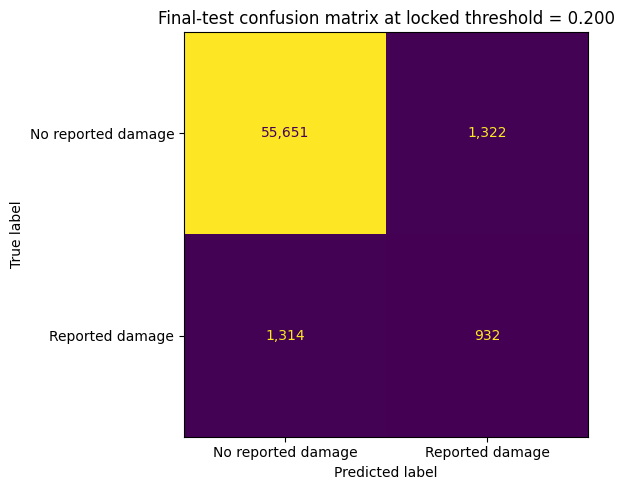

,Predicted no damage,Predicted damage
Actual no damage,55651,1322
Actual damage,1314,932


In [8]:
locked_prediction = (final_probability >= MAIN_THRESHOLD).astype(int)
cm = confusion_matrix(y_test, locked_prediction, labels=[0, 1])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["No reported damage", "Reported damage"]).plot(
    ax=ax, values_format=",", colorbar=False
)
ax.set_title(f"Final-test confusion matrix at locked threshold = {MAIN_THRESHOLD:.3f}")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_locked_threshold_confusion_matrix.png", dpi=160, bbox_inches="tight")
plt.show()

cm_table = pd.DataFrame(
    cm,
    index=["Actual no damage", "Actual damage"],
    columns=["Predicted no damage", "Predicted damage"],
)
display(cm_table)

### Interpretation — locked-threshold confusion matrix

At the locked maximum-validation-F1 threshold of 0.20, the final calibrated model correctly classified 55,651 non-damaging strikes and 932 damaging strikes. It produced 1,322 false positives and 1,314 false negatives. The nearly similar number of false positives and false negatives reflects the classification trade-off selected in Notebook 06 rather than an attempt to maximize overall accuracy. False negatives remain substantively important because 1,314 damaging incidents received probabilities below the selected classification threshold. However, this threshold is used only for classification summaries and local error examples; the downstream simulation consumes the continuous calibrated probabilities rather than binary classifications.

# 8. Notebook 04 diagnostic refresh before model explanations

Notebook 04 asked whether observed factors were associated with reported aircraft damage before the nonlinear predictive models were interpreted. The main carried-forward findings to keep in mind are:

- **wildlife size** showed a strong association with reported damage;
- **aircraft mass** showed a substantial association with reported damage;
- **phase of flight** showed meaningful differences in damage occurrence;
- **number struck** was associated with damage but its marginal effect was smaller than the strongest size/mass/phase patterns;
- theoretically motivated interactions among **wildlife size, aircraft mass, and phase of flight** were examined;
- these are observational associations and were not interpreted causally.

The comparison later in this notebook asks whether the fitted model relies on the same broad signals. Agreement increases plausibility; disagreement triggers investigation rather than automatic rejection because nonlinear models can redistribute predictive information among correlated features and interactions.

In [9]:
diagnostic_refresh = pd.DataFrame([
    ["SIZE", "Strong association", "Direction/importance should be inspected explicitly"],
    ["AC_MASS_GROUP", "Substantial association", "Direction/importance should be inspected explicitly"],
    ["PHASE_OF_FLIGHT", "Meaningful group differences", "Inspect category-specific SHAP behaviour"],
    ["NUM_STRUCK", "Associated; smaller marginal signal than strongest factors", "Check whether nonlinear/context interactions increase predictive use"],
    ["WARNED", "Formally assessed in diagnostic stage", "Interpret cautiously; not a causal intervention effect"],
    ["SIZE × AC_MASS_GROUP", "Interaction examined", "Look for context-dependent SHAP patterns"],
    ["SIZE × PHASE_OF_FLIGHT", "Interaction examined", "Look for context-dependent SHAP patterns"],
], columns=["factor", "Notebook_04_refresh", "Notebook_09_question"])

display(diagnostic_refresh)
diagnostic_refresh.to_csv(OUTPUT_DIR / "09_notebook04_diagnostic_refresh.csv", index=False)

,factor,Notebook_04_refresh,Notebook_09_question
0,SIZE,Strong association,Direction/importance should be inspected expli...
1,AC_MASS_GROUP,Substantial association,Direction/importance should be inspected expli...
2,PHASE_OF_FLIGHT,Meaningful group differences,Inspect category-specific SHAP behaviour
3,NUM_STRUCK,Associated; smaller marginal signal than stron...,Check whether nonlinear/context interactions i...
4,WARNED,Formally assessed in diagnostic stage,Interpret cautiously; not a causal interventio...
5,SIZE × AC_MASS_GROUP,Interaction examined,Look for context-dependent SHAP patterns
6,SIZE × PHASE_OF_FLIGHT,Interaction examined,Look for context-dependent SHAP patterns


# 9. Permutation importance on original scenario variables

Permutation importance is calculated on an untouched final-test subsample and uses **average precision / PR-AUC** as the scoring metric. The displayed number is the mean decrease in held-out PR-AUC after shuffling one original input while leaving all others unchanged.

A larger positive decrease means the final calibrated system relied more strongly on that feature's information for discrimination in this evaluation sample. Negative or near-zero values can occur because of sampling variation, feature redundancy, interactions, or correlated predictors.

In [10]:
perm_n = min(PERMUTATION_SAMPLE_N, len(test_df))
perm_sample = test_df.sample(n=perm_n, random_state=SEED)
X_perm = perm_sample[SELECTED_FEATURES]
y_perm = perm_sample[TARGET].astype(int)

baseline_perm_pr_auc = average_precision_score(
    y_perm,
    final_model.predict_proba(X_perm)[:, 1]
)

perm = permutation_importance(
    final_model,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=PERMUTATION_REPEATS,
    random_state=SEED,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": SELECTED_FEATURES,
    "importance_mean_pr_auc_drop": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean_pr_auc_drop", ascending=False).reset_index(drop=True)
perm_df["rank"] = np.arange(1, len(perm_df) + 1)

print("Permutation sample PR-AUC:", round(baseline_perm_pr_auc, 4))
display(perm_df)
perm_df.to_csv(OUTPUT_DIR / "09_permutation_importance_original_features.csv", index=False)

Permutation sample PR-AUC: 0.3376


,feature,importance_mean_pr_auc_drop,importance_std,rank
0,SIZE,0.220183,0.007325,1
1,AC_MASS_GROUP,0.088840,0.013180,2
2,HEIGHT,0.037654,0.006962,3
3,PHASE_OF_FLIGHT,0.024533,0.001741,4
4,AIRPORT_ID,0.022565,0.001760,5
5,WILDLIFE_TYPE,0.019291,0.003728,6
6,NUM_STRUCK,0.016202,0.002944,7
7,TYPE_ENG,0.012793,0.001771,8
8,SPEED,0.011072,0.001238,9
9,MONTH_COS,0.010646,0.002592,10


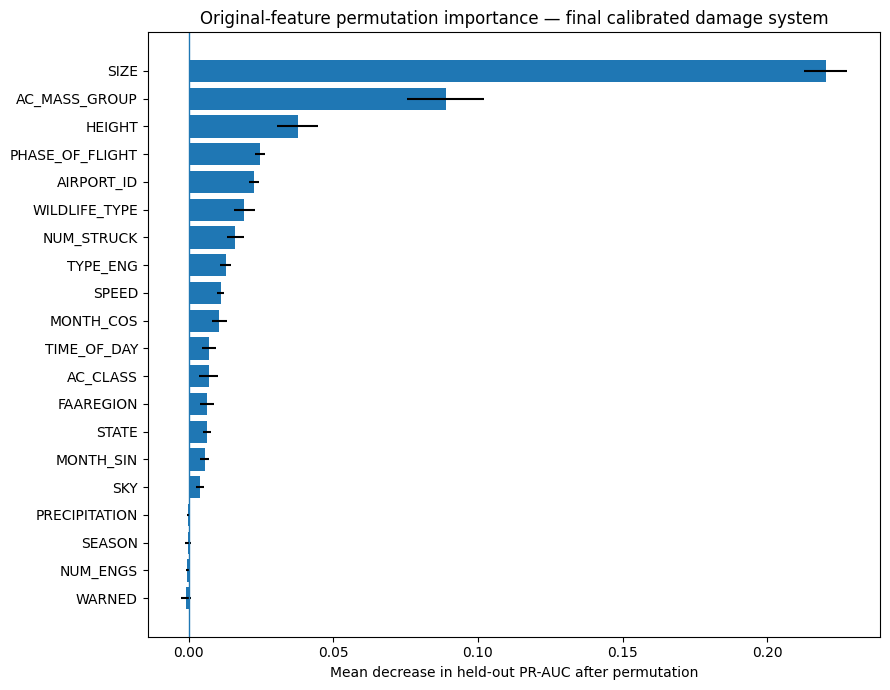

In [11]:
plot_perm = perm_df.sort_values("importance_mean_pr_auc_drop", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(plot_perm))))
ax.barh(
    plot_perm["feature"],
    plot_perm["importance_mean_pr_auc_drop"],
    xerr=plot_perm["importance_std"],
)
ax.axvline(0, linewidth=1)
ax.set_xlabel("Mean decrease in held-out PR-AUC after permutation")
ax.set_title("Original-feature permutation importance — final calibrated damage system")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_permutation_importance_original_features.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretation — permutation importance

Permutation importance identifies `SIZE` as the strongest unique contributor to held-out discrimination: shuffling wildlife size reduced PR-AUC by approximately 0.220. `AC_MASS_GROUP` was second with a reduction of approximately 0.089, followed by `HEIGHT` (0.038), `PHASE_OF_FLIGHT` (0.025), `AIRPORT_ID` (0.023), `WILDLIFE_TYPE` (0.019), and `NUM_STRUCK` (0.016).

These results support the research emphasis on wildlife, aircraft, and flight-context characteristics. Wildlife size in particular contains predictive information that other variables cannot easily replace. Aircraft mass is also highly informative, while phase of flight and number struck provide smaller but meaningful incremental contributions.

Geographic information contributes to discrimination, but `AIRPORT_ID` ranks fifth rather than dominating the model. State and FAA region contribute additional but smaller unique information. Temporal information is also present, particularly through cyclical month variables, although `SEASON` itself contributes almost no unique permutation importance.

`WARNED`, `NUM_ENGS`, `SEASON`, and `PRECIPITATION` have approximately zero or slightly negative permutation importance in this sample. This should not be interpreted as proof that these variables have no relationship with damage. Correlation, redundancy, nonlinear interactions, and sampling variability can allow other predictors to retain similar information after one feature is permuted.

# 10. Reproducible stratified SHAP sample

In [12]:
def proportional_stratified_sample(frame, n, seed):
    """Sample approximately proportionally within outcome × airport-status strata."""
    if len(frame) <= n:
        return frame.copy()

    work = frame.copy()
    work["_stratum"] = (
        work[TARGET].astype(str) + "__" + work["AIRPORT_SEEN_STATUS"].astype(str)
    )

    rng = np.random.default_rng(seed)
    chosen = []
    total = len(work)

    for _, group in work.groupby("_stratum", dropna=False):
        target_n = max(1, int(round(n * len(group) / total)))
        target_n = min(target_n, len(group))
        chosen.extend(rng.choice(group.index.to_numpy(), size=target_n, replace=False).tolist())

    # Reconcile rounding to exactly n where possible.
    chosen = list(dict.fromkeys(chosen))
    if len(chosen) > n:
        chosen = rng.choice(np.array(chosen), size=n, replace=False).tolist()
    elif len(chosen) < n:
        remaining = work.index.difference(chosen).to_numpy()
        add_n = min(n - len(chosen), len(remaining))
        if add_n:
            chosen.extend(rng.choice(remaining, size=add_n, replace=False).tolist())

    return work.loc[chosen].drop(columns="_stratum").copy()

shap_sample = proportional_stratified_sample(test_df, SHAP_SAMPLE_N, SEED)

sample_check = (
    shap_sample.groupby([TARGET, "AIRPORT_SEEN_STATUS"])
    .size()
    .rename("sample_rows")
    .reset_index()
)

display(sample_check)
print(f"SHAP sample rows: {len(shap_sample):,} of {len(test_df):,} final-test rows")

,INDICATED_DAMAGE,AIRPORT_SEEN_STATUS,sample_rows
0,0,seen_airport,4799
1,0,unseen_airport,11
2,1,seen_airport,184
3,1,unseen_airport,6


SHAP sample rows: 5,000 of 59,219 final-test rows


# 11. TreeSHAP on transformed features — technical view

In [13]:
X_shap_original = shap_sample[SELECTED_FEATURES]
X_shap_transformed = preprocessor.transform(X_shap_original)

explainer = shap.TreeExplainer(
    base_tree_model,
    feature_perturbation="tree_path_dependent",
    model_output="raw",
)

shap_values = explainer(X_shap_transformed)

# Normalize binary-class output shape if a SHAP version returns an extra class axis.
values = np.asarray(shap_values.values)
if values.ndim == 3 and values.shape[-1] == 2:
    values = values[:, :, 1]

assert values.shape[0] == len(shap_sample)
assert values.shape[1] == len(transformed_feature_names)

transformed_shap_importance = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "mean_abs_shap_raw_log_odds": np.abs(values).mean(axis=0),
    "mean_signed_shap_raw_log_odds": values.mean(axis=0),
}).sort_values("mean_abs_shap_raw_log_odds", ascending=False).reset_index(drop=True)
transformed_shap_importance["rank"] = np.arange(1, len(transformed_shap_importance) + 1)

display(transformed_shap_importance.head(40))
transformed_shap_importance.to_csv(
    OUTPUT_DIR / "09_shap_transformed_feature_importance.csv", index=False
)

,transformed_feature,mean_abs_shap_raw_log_odds,mean_signed_shap_raw_log_odds,rank
0,categorical__AC_MASS_GROUP_Unknown,1.030756,-0.915004,1
1,categorical__SIZE_Small,0.600818,-0.312814,2
2,categorical__PHASE_OF_FLIGHT_Not reported,0.207337,-0.114163,3
3,categorical__AC_CLASS_Not reported,0.189328,-0.139379,4
4,categorical__SIZE_Large,0.187410,-0.102140,5
5,categorical__SIZE_Medium,0.153205,-0.109343,6
6,categorical__AC_MASS_GROUP_Light,0.136343,-0.049105,7
7,num_struck_ordinal__NUM_STRUCK,0.135705,-0.056711,8
8,numeric__MONTH_COS,0.123956,-0.029203,9
9,categorical__AC_MASS_GROUP_Heavy,0.122419,-0.013157,10


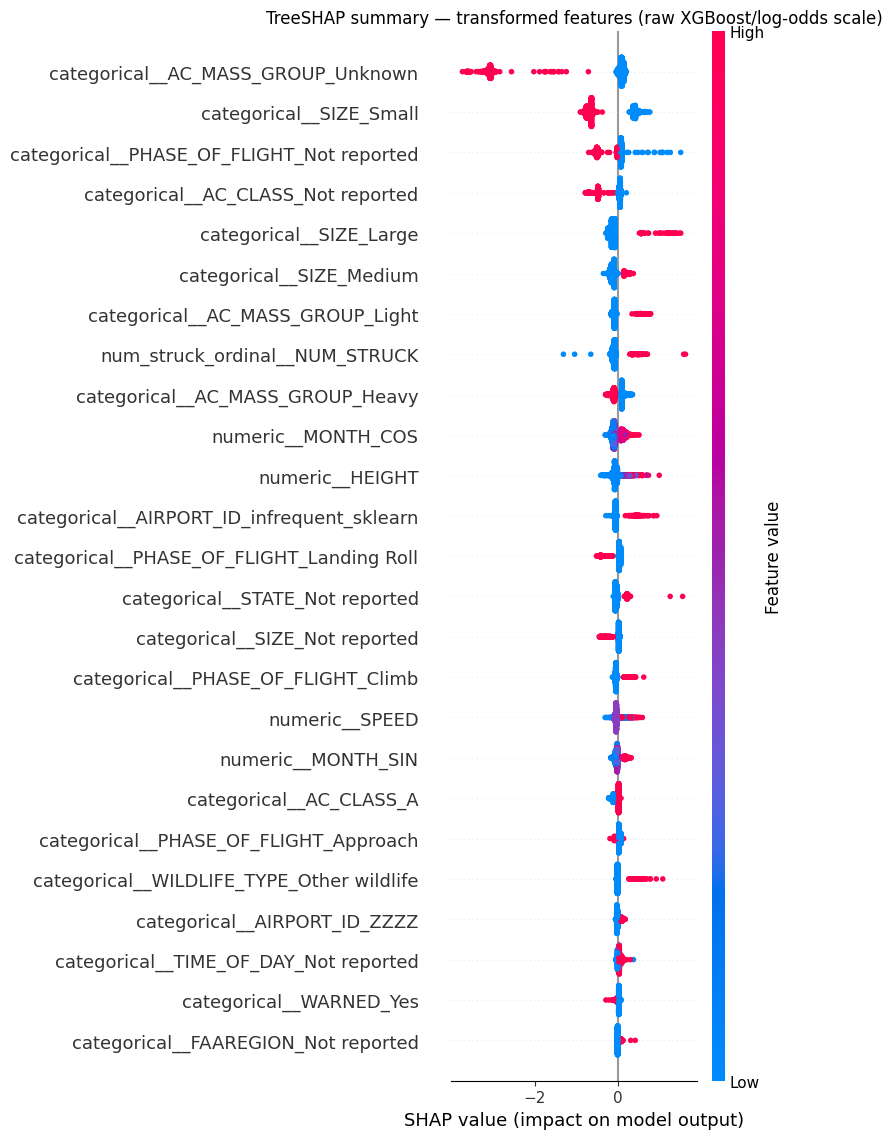

In [14]:
# Display one ungrouped SHAP summary before aggregating to original variables.
# A smaller plotting subset reduces dense-memory requirements without changing
# the attribution table computed on the full SHAP sample.
plot_n = min(1500, len(shap_sample))
plot_positions = np.random.default_rng(SEED).choice(
    np.arange(len(shap_sample)), size=plot_n, replace=False
)

X_plot = X_shap_transformed[plot_positions]
if hasattr(X_plot, "toarray"):
    X_plot = X_plot.toarray()

plt.figure(figsize=(10, 8))
shap.summary_plot(
    values[plot_positions],
    X_plot,
    feature_names=transformed_feature_names,
    max_display=25,
    show=False,
)
plt.title("TreeSHAP summary — transformed features (raw XGBoost/log-odds scale)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_shap_summary_transformed_features.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretation — transformed SHAP view

The ungrouped TreeSHAP results show that the model's strongest transformed features are individual categories belonging primarily to aircraft mass, wildlife size, and phase of flight. In particular, the encoded `AC_MASS_GROUP_Unknown` term produces the largest average absolute attribution, followed by `SIZE_Small`, `PHASE_OF_FLIGHT_Not reported`, `AC_CLASS_Not reported`, and the Large and Medium wildlife-size indicators.

This view is valuable as a technical audit because it shows exactly which encoded columns the XGBoost estimator uses. It also reveals that missing or unknown categories can themselves carry substantial predictive information, especially for aircraft mass and flight phase. This is plausible because reporting completeness differs across incidents, but such effects should be understood partly as documentation patterns rather than physical characteristics.

Because categorical predictors are represented by multiple encoded columns, the transformed ranking should not be interpreted as the main substantive feature ranking. The following grouped SHAP analysis recombines these encoded terms into their original scenario variables.

# 12. Map transformed columns back to original scenario variables

In [15]:
def source_feature_from_transformed(name, original_features):
    # Remove ColumnTransformer prefix such as categorical__, numeric__, etc.
    body = str(name).split("__", 1)[-1]

    # Longest match prevents a shorter feature name from capturing a longer one.
    for feature in sorted(original_features, key=len, reverse=True):
        if body == feature or body.startswith(feature + "_"):
            return feature
    return "<UNMAPPED>"

transformed_to_source = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
})
transformed_to_source["source_feature"] = transformed_to_source[
    "transformed_feature"
].map(lambda x: source_feature_from_transformed(x, SELECTED_FEATURES))

unmapped = transformed_to_source.query("source_feature == '<UNMAPPED>'")
if len(unmapped):
    warnings.warn(
        f"{len(unmapped)} transformed features could not be mapped. Inspect before interpretation."
    )
    display(unmapped.head(30))

transformed_to_source.to_csv(
    OUTPUT_DIR / "09_transformed_to_original_feature_mapping.csv", index=False
)
display(transformed_to_source.head(30))

,transformed_feature,source_feature
0,numeric__MONTH_SIN,MONTH_SIN
1,numeric__MONTH_COS,MONTH_COS
2,numeric__NUM_ENGS,NUM_ENGS
3,numeric__HEIGHT,HEIGHT
4,numeric__SPEED,SPEED
5,num_struck_ordinal__NUM_STRUCK,NUM_STRUCK
6,categorical__SEASON_Autumn,SEASON
7,categorical__SEASON_Spring,SEASON
8,categorical__SEASON_Summer,SEASON
9,categorical__SEASON_Winter,SEASON


# 13. Grouped SHAP importance — primary global interpretation

In [16]:
source_names = transformed_to_source["source_feature"].to_numpy()
source_order = [f for f in SELECTED_FEATURES if f in set(source_names)]

abs_grouped = {}
signed_grouped = {}
for source in source_order:
    cols = np.where(source_names == source)[0]
    # For each observation, sum transformed attributions belonging to the original input.
    grouped_signed_per_row = values[:, cols].sum(axis=1)
    signed_grouped[source] = grouped_signed_per_row
    abs_grouped[source] = np.abs(grouped_signed_per_row)

grouped_signed_df = pd.DataFrame(signed_grouped, index=shap_sample.index)
grouped_abs_df = pd.DataFrame(abs_grouped, index=shap_sample.index)

grouped_importance = pd.DataFrame({
    "feature": source_order,
    "mean_abs_grouped_shap": [grouped_abs_df[c].mean() for c in source_order],
    "mean_signed_grouped_shap": [grouped_signed_df[c].mean() for c in source_order],
}).sort_values("mean_abs_grouped_shap", ascending=False).reset_index(drop=True)

grouped_importance["share_of_total_mean_abs_shap"] = (
    grouped_importance["mean_abs_grouped_shap"]
    / grouped_importance["mean_abs_grouped_shap"].sum()
)
grouped_importance["rank"] = np.arange(1, len(grouped_importance) + 1)

display(grouped_importance)
grouped_importance.to_csv(OUTPUT_DIR / "09_shap_grouped_original_feature_importance.csv", index=False)

,feature,mean_abs_grouped_shap,mean_signed_grouped_shap,share_of_total_mean_abs_shap,rank
0,AC_MASS_GROUP,1.135927,-0.977267,0.327067,1
1,SIZE,0.810233,-0.570985,0.233290,2
2,PHASE_OF_FLIGHT,0.286234,-0.167844,0.082415,3
3,AC_CLASS,0.240144,-0.174347,0.069145,4
4,NUM_STRUCK,0.135705,-0.056711,0.039073,5
5,AIRPORT_ID,0.132452,-0.039742,0.038137,6
6,MONTH_COS,0.123956,-0.029203,0.035691,7
7,HEIGHT,0.112291,-0.030332,0.032332,8
8,STATE,0.098940,-0.012212,0.028488,9
9,WILDLIFE_TYPE,0.070410,-0.007052,0.020273,10


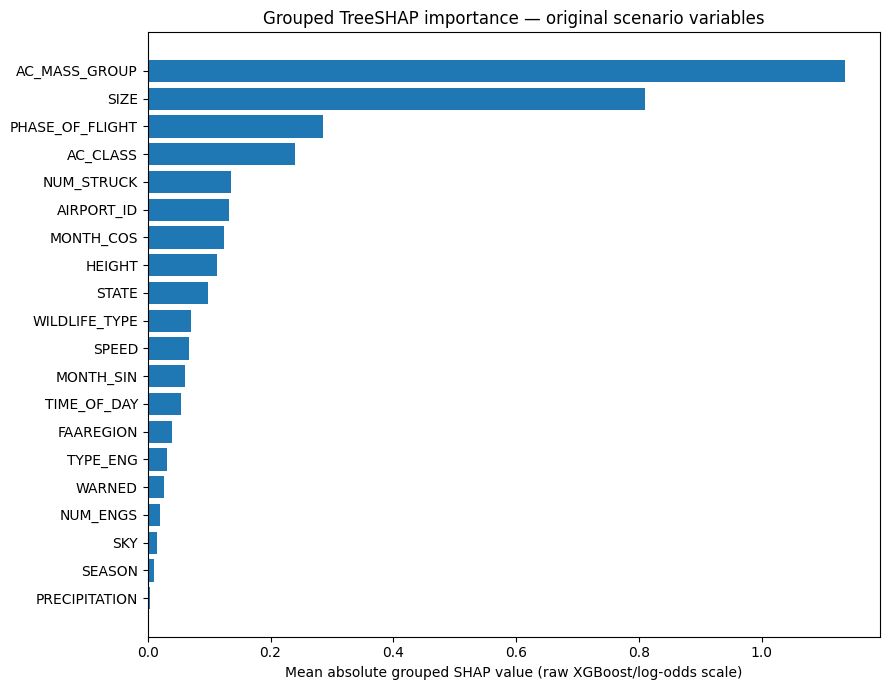

In [17]:
plot_grouped = grouped_importance.sort_values("mean_abs_grouped_shap", ascending=True)
fig, ax = plt.subplots(figsize=(9, max(6, 0.35 * len(plot_grouped))))
ax.barh(plot_grouped["feature"], plot_grouped["mean_abs_grouped_shap"])
ax.set_xlabel("Mean absolute grouped SHAP value (raw XGBoost/log-odds scale)")
ax.set_title("Grouped TreeSHAP importance — original scenario variables")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_shap_grouped_original_features.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretation — grouped SHAP

After recombining encoded columns into their original scenario variables, aircraft mass is the strongest global driver of the underlying XGBoost score, accounting for approximately 32.7% of total mean absolute SHAP attribution. Wildlife size accounts for another 23.3%. Together, these two factors represent approximately 56.0% of the model's global attribution magnitude.

Phase of flight ranks third at 8.2%, aircraft class fourth at 6.9%, and number struck fifth at 3.9%. Airport identity ranks sixth at 3.8%. Month, height, state, wildlife type, speed, time of day, FAA region, and other scenario features contribute smaller amounts.

The model is therefore not relying primarily on a single airport identifier or temporal shortcut. Its dominant information comes from wildlife and aircraft characteristics, with additional contribution from flight context, geography, and time. This structure is substantively plausible and broadly consistent with the diagnostic findings from Notebook 04.

# 14. Direction and storytelling for research-question variables

Global importance alone does not say *how* a variable changes the model score. This section intentionally inspects the research-question variables even if some are not globally top-ranked.

For numeric/ordinal inputs, plots compare the original value with grouped SHAP contribution. For categorical inputs, tables summarize mean signed SHAP by category together with support counts. Categories with very few observations must not be overinterpreted.

In [18]:
PRIORITY_FEATURES = [
    c for c in [
        "SIZE", "AC_MASS_GROUP", "PHASE_OF_FLIGHT", "NUM_STRUCK",
        "AIRPORT_ID", "STATE", "FAAREGION", "SEASON",
        "MONTH_SIN", "MONTH_COS", "TIME_OF_DAY"
    ]
    if c in SELECTED_FEATURES
]

priority_summary_rows = []
for feature in PRIORITY_FEATURES:
    priority_summary_rows.append({
        "feature": feature,
        "grouped_shap_rank": int(
            grouped_importance.loc[grouped_importance["feature"].eq(feature), "rank"].iloc[0]
        ),
        "mean_abs_grouped_shap": float(grouped_abs_df[feature].mean()),
        "mean_signed_grouped_shap": float(grouped_signed_df[feature].mean()),
    })

priority_summary = pd.DataFrame(priority_summary_rows).sort_values("grouped_shap_rank")
display(priority_summary)
priority_summary.to_csv(OUTPUT_DIR / "09_priority_feature_shap_summary.csv", index=False)

,feature,grouped_shap_rank,mean_abs_grouped_shap,mean_signed_grouped_shap
1,AC_MASS_GROUP,1,1.135927,-0.977267
0,SIZE,2,0.810233,-0.570985
2,PHASE_OF_FLIGHT,3,0.286234,-0.167844
3,NUM_STRUCK,5,0.135705,-0.056711
4,AIRPORT_ID,6,0.132452,-0.039742
9,MONTH_COS,7,0.123956,-0.029203
5,STATE,9,0.098940,-0.012212
8,MONTH_SIN,12,0.060915,-0.013901
10,TIME_OF_DAY,13,0.054445,0.019335
6,FAAREGION,14,0.039459,-0.002026



SIZE


,value,count,mean_shap,median_shap,mean_abs_shap
0,Large,231,1.423950,1.637326,1.423950
3,Small,3282,-0.949354,-0.986326,0.949354
1,Medium,527,0.509358,0.504985,0.509358
2,Not reported,960,-0.350528,-0.372904,0.352105


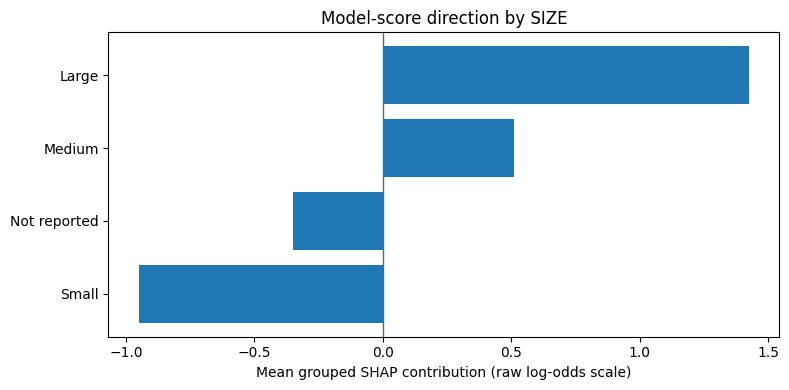


AC_MASS_GROUP


,value,count,mean_shap,median_shap,mean_abs_shap
3,Unknown,1588,-3.077433,-3.072781,3.077433
1,Light,389,0.866094,0.852840,0.866094
2,Medium,265,0.217228,0.208756,0.217228
0,Heavy,2758,-0.142802,-0.119801,0.144377


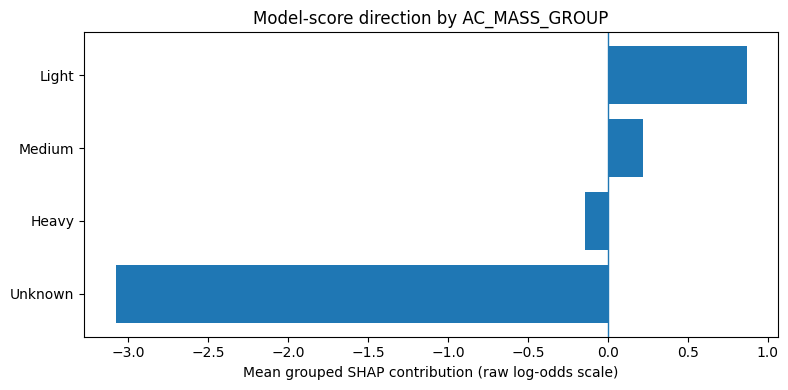


PHASE_OF_FLIGHT


,value,count,mean_shap,median_shap,mean_abs_shap
2,Climb,330,0.447521,0.456784,0.447521
6,Landing Roll,520,-0.378528,-0.408990,0.401168
8,Not reported,2237,-0.378576,-0.530406,0.385142
4,Descent,48,0.371279,0.352739,0.371279
7,Local,28,-0.015807,-0.210333,0.348899
5,En Route,77,0.316352,0.299388,0.316352
3,Departure,107,-0.223394,-0.247664,0.223394
9,Take-off Run,410,0.179892,0.162453,0.179892
1,Arrival,34,0.086894,0.067891,0.086894
0,Approach,1198,-0.031229,-0.042508,0.049940


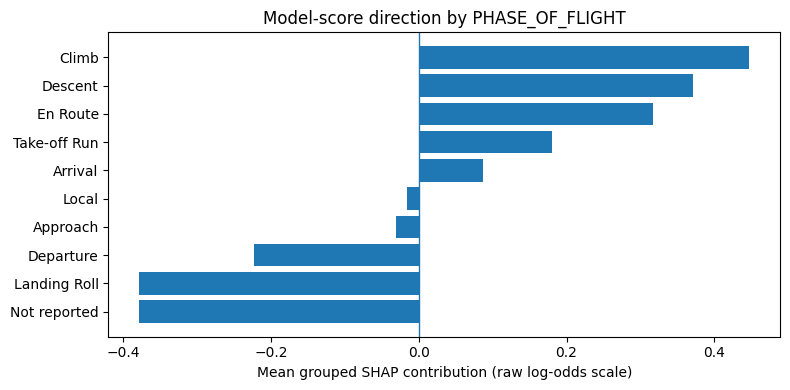


NUM_STRUCK


,value,count,mean_shap,median_shap,mean_abs_shap
2,2–10,409,0.451606,0.459807,0.451606
0,1,4573,-0.103228,-0.098022,0.103228


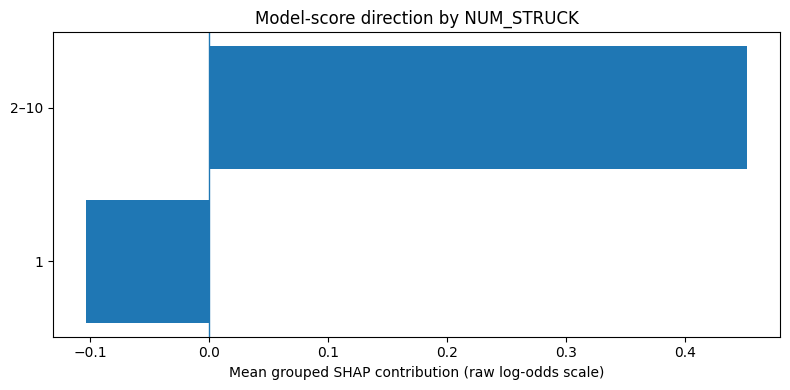


FAAREGION


,value,count,mean_shap,median_shap,mean_abs_shap
9,FGN,74,-0.095237,-0.090150,0.095237
10,Not reported,774,0.089531,0.083802,0.089531
6,ASO,1108,-0.053369,-0.051390,0.053426
4,ANE,163,-0.040677,-0.036677,0.040677
5,ANM,497,0.033587,0.024671,0.034058
7,ASW,606,-0.023859,-0.018241,0.024407
8,AWP,476,-0.015702,-0.013228,0.016316
2,AEA,487,-0.011723,-0.012320,0.013554
3,AGL,615,0.006358,0.002432,0.011892
0,AAL,22,-0.002172,-0.005010,0.009306


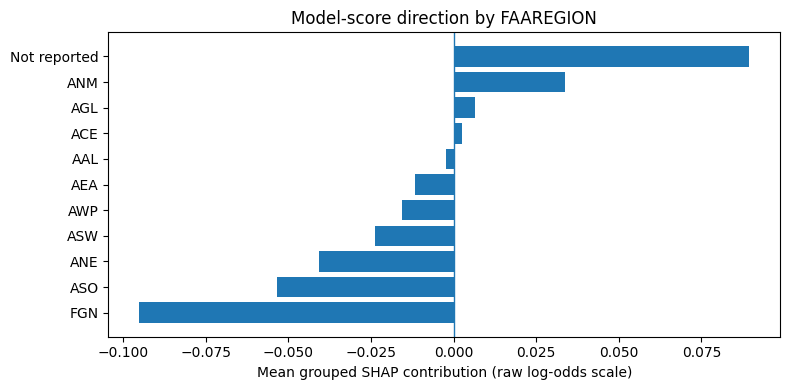


SEASON


,value,count,mean_shap,median_shap,mean_abs_shap
3,Winter,446,0.017654,0.016122,0.018144
2,Summer,1744,-0.002462,-0.003031,0.010041
0,Autumn,1776,-0.005842,-0.004472,0.009943
1,Spring,1034,0.003962,0.003533,0.007041


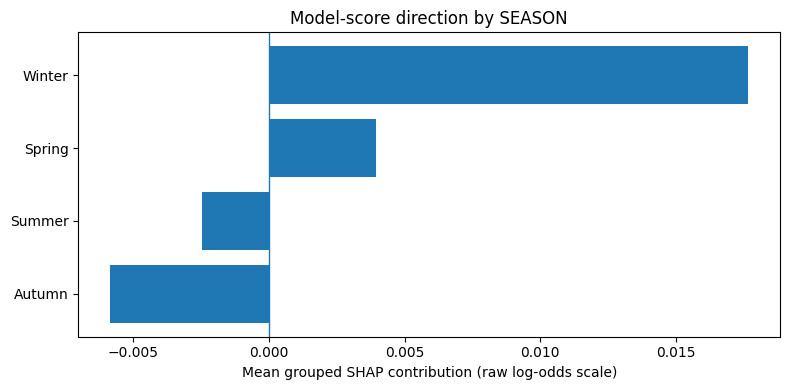


TIME_OF_DAY


,value,count,mean_shap,median_shap,mean_abs_shap
2,Dusk,110,0.101121,0.094527,0.101121
3,Night,857,-0.055502,-0.053027,0.076627
4,Not reported,2407,0.056787,0.026741,0.057119
1,Day,1557,-0.002284,-0.003747,0.036515
0,Dawn,69,-0.000206,-0.001923,0.015812


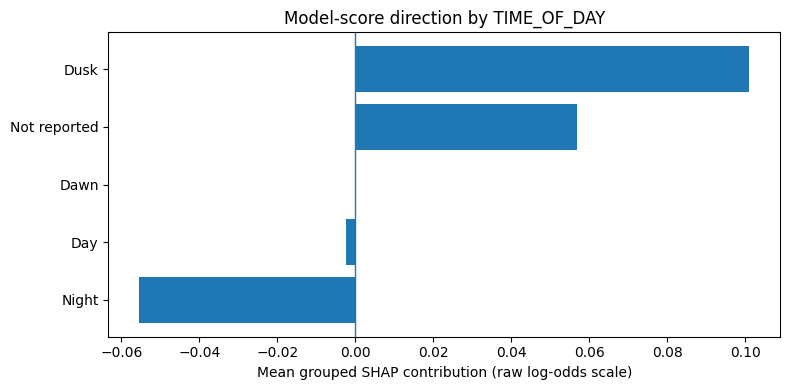

In [19]:
def categorical_shap_summary(feature, min_count=20, top_n=20):
    temp = pd.DataFrame({
        "value": shap_sample[feature].astype("string").fillna("<MISSING>"),
        "shap": grouped_signed_df[feature],
    })
    out = (
        temp.groupby("value", dropna=False)["shap"]
        .agg(count="size", mean_shap="mean", median_shap="median", mean_abs_shap=lambda s: np.abs(s).mean())
        .reset_index()
    )
    out = out.loc[out["count"] >= min_count]
    return out.sort_values("mean_abs_shap", ascending=False).head(top_n)

for feature in [c for c in ["SIZE", "AC_MASS_GROUP", "PHASE_OF_FLIGHT", "NUM_STRUCK", "FAAREGION", "SEASON", "TIME_OF_DAY"] if c in PRIORITY_FEATURES]:
    summary = categorical_shap_summary(feature)
    print(f"\n{feature}")
    display(summary)
    summary.to_csv(OUTPUT_DIR / f"09_shap_direction_{feature.lower()}.csv", index=False)

    if len(summary):
        plot = summary.sort_values("mean_shap")
        fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(plot))))
        ax.barh(plot["value"].astype(str), plot["mean_shap"])
        ax.axvline(0, linewidth=1)
        ax.set_xlabel("Mean grouped SHAP contribution (raw log-odds scale)")
        ax.set_title(f"Model-score direction by {feature}")
        plt.tight_layout()
        fig.savefig(OUTPUT_DIR / f"09_shap_direction_{feature.lower()}.png", dpi=160, bbox_inches="tight")
        plt.show()

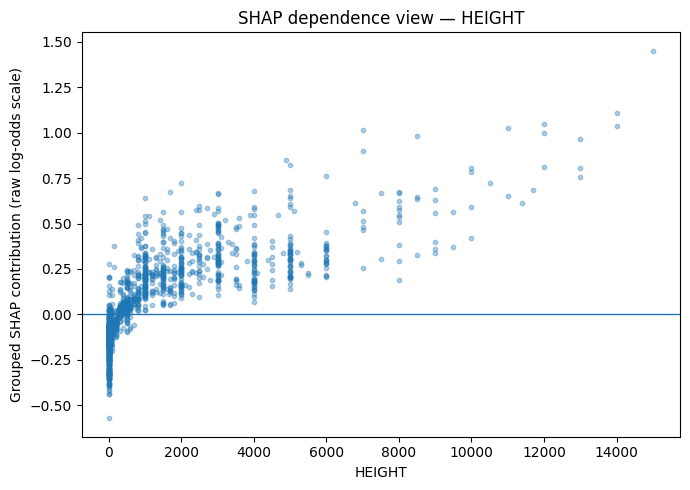

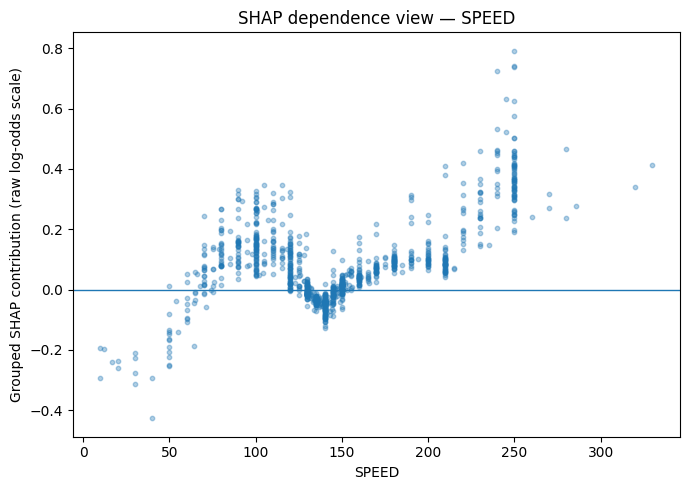

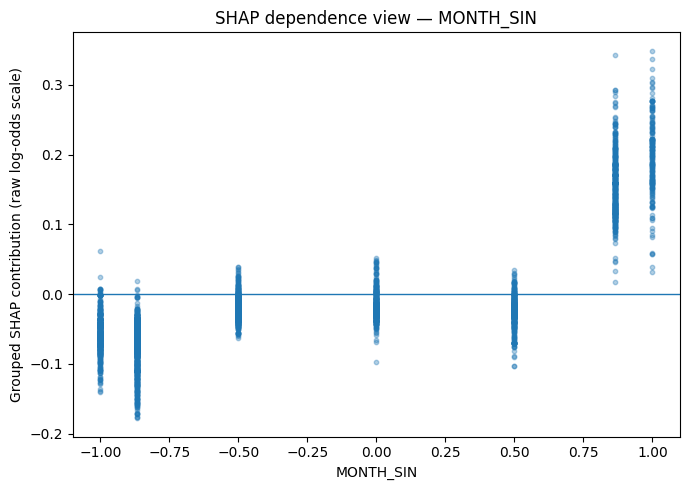

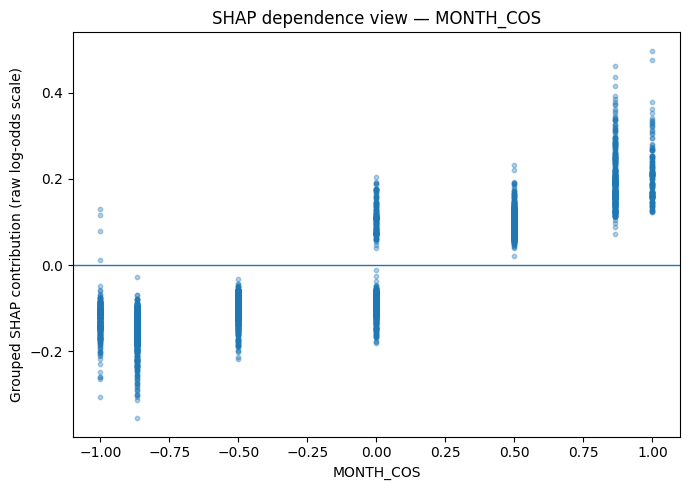

In [20]:
for feature in [c for c in ["HEIGHT", "SPEED", "MONTH_SIN", "MONTH_COS"] if c in PRIORITY_FEATURES or c in SELECTED_FEATURES]:
    x = pd.to_numeric(shap_sample[feature], errors="coerce")
    y = grouped_signed_df[feature]
    valid = x.notna()
    if valid.sum() < 20:
        continue

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.scatter(x[valid], y[valid], s=10, alpha=0.35)
    ax.axhline(0, linewidth=1)
    ax.set_xlabel(feature)
    ax.set_ylabel("Grouped SHAP contribution (raw log-odds scale)")
    ax.set_title(f"SHAP dependence view — {feature}")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"09_shap_dependence_{feature.lower()}.png", dpi=160, bbox_inches="tight")
    plt.show()

### Interpretation — direction

The directional SHAP results show the clearest and most substantively coherent pattern for wildlife size. `Large` wildlife has a strongly positive mean grouped SHAP contribution (+1.424 raw log-odds units), `Medium` wildlife is also positive (+0.509), while `Small` wildlife is strongly negative (-0.949). Within the fitted model, larger wildlife therefore tends to move the raw damage score upward and small wildlife tends to move it downward, conditional on the other available predictors.

`NUM_STRUCK` shows a similarly interpretable pattern for the well-supported categories. A single animal has a modest negative mean contribution (-0.103), whereas `2–10` animals has a positive contribution (+0.452). This agrees with the project hypothesis that multiple animals struck can represent a more damaging scenario, although the overall importance of number struck remains smaller than wildlife size or aircraft mass.

`PHASE_OF_FLIGHT` is context-specific rather than ordinal. Climb (+0.448), Descent (+0.371), En Route (+0.316), and Take-off Run (+0.180) tend to move the raw score upward on average, whereas Landing Roll (-0.379), Departure (-0.223), and the `Not reported` category (-0.379) tend to move it downward. Approach is comparatively close to neutral. These are conditional model effects and should not be interpreted as causal effects of a flight phase.

Aircraft mass is globally the most influential original feature, but its directional pattern is nonlinear. `Light` (+0.866) and `Medium` (+0.217) contribute positively on average, `Heavy` is slightly negative (-0.143), and `Unknown` is strongly negative (-3.077). This does **not** imply that lighter aircraft intrinsically cause more damage. Aircraft mass is used jointly with aircraft class, wildlife size, phase of flight, and reporting-completeness information. The strong `Unknown` effect is therefore also a warning that documentation status itself contains predictive information.

Broad `SEASON` contributes very little after the cyclical month variables and other scenario information are available. The month sine/cosine features rank above `SEASON`, suggesting that finer within-year timing patterns retain more predictive information than the four broad seasonal categories. Geographic-region and time-of-day effects are present but substantially smaller than the dominant wildlife and aircraft factors.

All SHAP directions describe how the fitted model changes its **raw XGBoost score**. They are not probability-point changes and do not establish causal mechanisms.


# 15. Temporal explanation stability: 2022 vs 2023 vs 2024

In [21]:
def grouped_importance_for_index(index_values):
    subset_abs = grouped_abs_df.loc[index_values]
    return subset_abs.mean(axis=0).sort_values(ascending=False)

year_importance = {}
for year in sorted(shap_sample["INCIDENT_YEAR"].dropna().unique()):
    idx = shap_sample.index[shap_sample["INCIDENT_YEAR"].eq(year)]
    if len(idx) >= 30:
        year_importance[str(int(year))] = grouped_importance_for_index(idx)

year_importance_df = pd.DataFrame(year_importance).fillna(0)
year_importance_df.index.name = "feature"
year_importance_df.to_csv(OUTPUT_DIR / "09_shap_importance_by_year.csv")
display(year_importance_df)

# Spearman rank agreement between years.
year_rank_corr = year_importance_df.rank(ascending=False).corr(method="spearman")
year_rank_corr.to_csv(OUTPUT_DIR / "09_shap_year_rank_spearman.csv")
display(year_rank_corr.round(3))

,2022,2023,2024
feature,,,
AC_CLASS,0.239669,0.237466,0.242896
AC_MASS_GROUP,1.151593,1.114006,1.143278
AIRPORT_ID,0.133362,0.130399,0.133573
FAAREGION,0.038097,0.040610,0.039490
HEIGHT,0.114500,0.111256,0.111500
MONTH_COS,0.121480,0.124771,0.125153
MONTH_SIN,0.062913,0.061695,0.058673
NUM_ENGS,0.020084,0.018766,0.019327
NUM_STRUCK,0.138061,0.135513,0.134048


,2022,2023,2024
2022,1.000,0.998,1.000
2023,0.998,1.000,0.998
2024,1.000,0.998,1.000


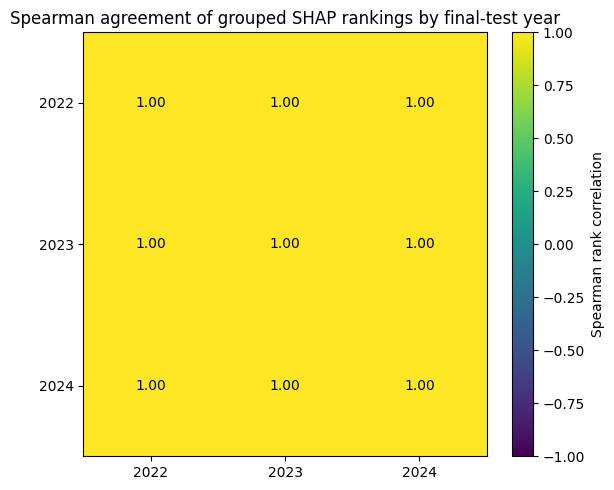

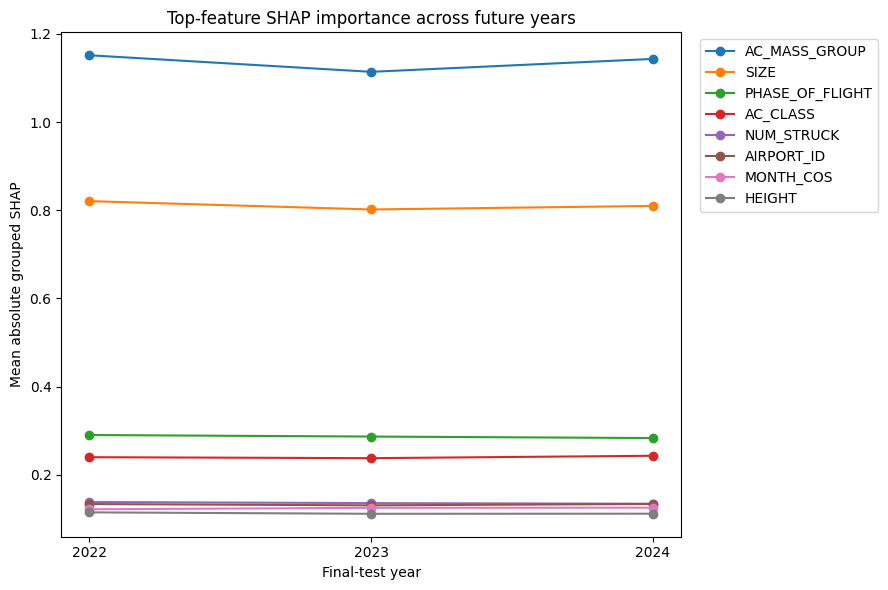

In [22]:
if year_importance_df.shape[1] >= 2:
    matrix = year_importance_df.rank(ascending=False).corr(method="spearman").to_numpy()
    labels = year_rank_corr.columns.tolist()

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(matrix, vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(labels)), labels)
    ax.set_yticks(range(len(labels)), labels)
    ax.set_title("Spearman agreement of grouped SHAP rankings by final-test year")
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f"{matrix[i, j]:.2f}", ha="center", va="center")
    fig.colorbar(im, ax=ax, label="Spearman rank correlation")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "09_shap_year_rank_stability.png", dpi=160, bbox_inches="tight")
    plt.show()

    top_story = grouped_importance.head(min(8, len(grouped_importance)))["feature"].tolist()
    fig, ax = plt.subplots(figsize=(9, 6))
    for feature in top_story:
        ax.plot(year_importance_df.columns, year_importance_df.loc[feature], marker="o", label=feature)
    ax.set_ylabel("Mean absolute grouped SHAP")
    ax.set_xlabel("Final-test year")
    ax.set_title("Top-feature SHAP importance across future years")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "09_shap_top_features_by_year.png", dpi=160, bbox_inches="tight")
    plt.show()

### Interpretation — temporal stability

Global explanations were highly stable across the three locked future years. Spearman rank correlations between yearly grouped-SHAP importance rankings ranged from 0.998 to 1.000. The leading variables also retained very similar attribution magnitudes: aircraft mass remained approximately 1.11–1.15 mean absolute SHAP, wildlife size approximately 0.80–0.82, and phase of flight approximately 0.28–0.29.

This provides strong evidence that the model did not materially change which information it relied upon from 2022 through 2024. Although predictive performance can vary between years, the explanation structure itself is exceptionally stable across the final-test period.

# 16. Airport-dependence and geographic explanation audit

In [23]:
AIRPORT_FEATURE = "AIRPORT_ID"

airport_audit_rows = []
if AIRPORT_FEATURE in grouped_importance["feature"].values:
    airport_row = grouped_importance.loc[grouped_importance["feature"].eq(AIRPORT_FEATURE)].iloc[0]
    airport_perm = perm_df.loc[perm_df["feature"].eq(AIRPORT_FEATURE)].iloc[0]
    airport_audit_rows.append({
        "measure": "Grouped SHAP importance rank",
        "value": float(airport_row["rank"]),
        "interpretation": "Lower numeric rank means greater attribution concentration",
    })
    airport_audit_rows.append({
        "measure": "Grouped SHAP share",
        "value": float(airport_row["share_of_total_mean_abs_shap"]),
        "interpretation": "Share of total grouped absolute attribution in SHAP sample",
    })
    airport_audit_rows.append({
        "measure": "Permutation importance rank",
        "value": float(airport_perm["rank"]),
        "interpretation": "Rank by final-test PR-AUC decrease after airport shuffle",
    })
    airport_audit_rows.append({
        "measure": "Permutation PR-AUC decrease",
        "value": float(airport_perm["importance_mean_pr_auc_drop"]),
        "interpretation": "Unique held-out discrimination lost when AIRPORT_ID is disrupted",
    })

airport_audit = pd.DataFrame(airport_audit_rows)
display(airport_audit)
airport_audit.to_csv(OUTPUT_DIR / "09_airport_dependence_summary.csv", index=False)

,measure,value,interpretation
0,Grouped SHAP importance rank,6.000000,Lower numeric rank means greater attribution c...
1,Grouped SHAP share,0.038137,Share of total grouped absolute attribution in...
2,Permutation importance rank,5.000000,Rank by final-test PR-AUC decrease after airpo...
3,Permutation PR-AUC decrease,0.022565,Unique held-out discrimination lost when AIRPO...


In [24]:
status_importance = {}
status_support = []
for status in ["seen_airport", "unseen_airport"]:
    idx = shap_sample.index[shap_sample["AIRPORT_SEEN_STATUS"].eq(status)]
    status_support.append({
        "airport_status": status,
        "shap_rows": len(idx),
        "damage_cases": int(shap_sample.loc[idx, TARGET].sum()),
    })
    if len(idx) >= 30:
        status_importance[status] = grouped_importance_for_index(idx)

status_support_df = pd.DataFrame(status_support)
status_importance_df = pd.DataFrame(status_importance).fillna(0)
status_importance_df.index.name = "feature"

display(status_support_df)
display(status_importance_df)
status_support_df.to_csv(OUTPUT_DIR / "09_shap_seen_unseen_support.csv", index=False)
status_importance_df.to_csv(OUTPUT_DIR / "09_shap_importance_seen_vs_unseen_airports.csv")

if status_importance_df.shape[1] == 2:
    rho, p = spearmanr(
        status_importance_df.iloc[:, 0].rank(ascending=False),
        status_importance_df.iloc[:, 1].rank(ascending=False),
    )
    seen_unseen_corr = pd.DataFrame([{
        "comparison": "seen_vs_unseen_airport_grouped_shap_rank",
        "spearman_rho": rho,
        "p_value_descriptive_only": p,
        "seen_rows": int(status_support_df.loc[status_support_df.airport_status.eq("seen_airport"), "shap_rows"].sum()),
        "unseen_rows": int(status_support_df.loc[status_support_df.airport_status.eq("unseen_airport"), "shap_rows"].sum()),
    }])
    display(seen_unseen_corr)
    seen_unseen_corr.to_csv(OUTPUT_DIR / "09_shap_seen_unseen_rank_spearman.csv", index=False)

,airport_status,shap_rows,damage_cases
0,seen_airport,4983,184
1,unseen_airport,17,6


,seen_airport
feature,
AC_MASS_GROUP,1.135924
SIZE,0.809117
PHASE_OF_FLIGHT,0.286425
AC_CLASS,0.240371
NUM_STRUCK,0.135803
AIRPORT_ID,0.131434
MONTH_COS,0.123976
HEIGHT,0.112058
STATE,0.099078


In [25]:
if status_importance_df.shape[1] == 2:
    compare = status_importance_df.copy()
    compare["mean"] = compare.mean(axis=1)
    top = compare.sort_values("mean", ascending=False).head(12).drop(columns="mean")

    x = np.arange(len(top))
    width = 0.38
    fig, ax = plt.subplots(figsize=(11, 6))
    ax.bar(x - width/2, top["seen_airport"], width, label="Seen airports")
    ax.bar(x + width/2, top["unseen_airport"], width, label="Unseen airports")
    ax.set_xticks(x, top.index, rotation=55, ha="right")
    ax.set_ylabel("Mean absolute grouped SHAP")
    ax.set_title("Explanation profile: seen versus unseen airports")
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "09_shap_seen_vs_unseen_airports.png", dpi=160, bbox_inches="tight")
    plt.show()

### 16.1 Dedicated seen-versus-unseen airport explanation sample

The global SHAP sample preserves the natural final-test distribution. Because genuinely unseen airports are rare, proportional sampling produced too few unseen-airport observations for a reliable explanation comparison.

A separate targeted diagnostic sample is therefore constructed using all available unseen-airport observations, subject to a computational cap, and an equally sized seeded sample of seen-airport observations.

This balancing is used only to compare explanation profiles. It does not replace the global SHAP sample, alter model-performance metrics, or change the natural prevalence of unseen airports in the final-test population.

In [26]:
# Dedicated geographic SHAP audit.
#
# The proportional global SHAP sample contained too few unseen-airport records,
# so this creates a balanced sample specifically for explanation comparison.
#
# IMPORTANT:
# Grouped SHAP is computed in exactly the same way as Section 13:
# 1) sum the signed transformed-feature SHAP values belonging to one original feature;
# 2) take the absolute value of that grouped signed contribution.
#
# Taking absolute values BEFORE summing one-hot columns would inflate multi-column
# categorical variables (especially AIRPORT_ID) and would not be comparable with
# the main grouped-SHAP analysis.

GEO_SHAP_MAX_PER_GROUP = 500
GEO_SHAP_SEED = SEED + 202

seen_geo_pool = test_df.loc[
    test_df["AIRPORT_SEEN_STATUS"].eq("seen_airport")
].copy()

unseen_geo_pool = test_df.loc[
    test_df["AIRPORT_SEEN_STATUS"].eq("unseen_airport")
].copy()

print("Available seen-airport final-test rows:", len(seen_geo_pool))
print("Available unseen-airport final-test rows:", len(unseen_geo_pool))

if len(unseen_geo_pool) == 0:
    raise RuntimeError(
        "No unseen-airport observations are available in the final-test population."
    )

geo_n = min(
    len(unseen_geo_pool),
    len(seen_geo_pool),
    GEO_SHAP_MAX_PER_GROUP,
)

if geo_n < 30:
    warnings.warn(
        f"Only {geo_n} observations per group are available. "
        "Interpret this comparison cautiously."
    )

unseen_geo_sample = unseen_geo_pool.sample(
    n=geo_n,
    random_state=GEO_SHAP_SEED,
)

seen_geo_sample = seen_geo_pool.sample(
    n=geo_n,
    random_state=GEO_SHAP_SEED,
)

geo_shap_sample = pd.concat(
    [seen_geo_sample, unseen_geo_sample],
    axis=0,
).sample(
    frac=1,
    random_state=GEO_SHAP_SEED,
)

geo_support = (
    geo_shap_sample
    .groupby("AIRPORT_SEEN_STATUS")[TARGET]
    .agg(
        rows="size",
        damage_cases="sum",
        damage_rate="mean",
    )
    .reset_index()
)

display(geo_support)

# Apply the exact same Notebook 05 preprocessing used by the raw XGBoost model.
X_geo_original = geo_shap_sample[SELECTED_FEATURES]
X_geo_transformed = preprocessor.transform(X_geo_original)

# Reuse the same TreeExplainer from the primary SHAP analysis.
geo_shap = explainer(X_geo_transformed)
geo_values = np.asarray(geo_shap.values)

if geo_values.ndim == 3 and geo_values.shape[-1] == 2:
    geo_values = geo_values[:, :, 1]

assert geo_values.shape[0] == len(geo_shap_sample)
assert geo_values.shape[1] == len(source_names)

# Aggregate transformed SHAP values back to the original scenario variables
# using the SAME signed-sum-then-absolute rule as Section 13.
geo_grouped_abs = pd.DataFrame(
    index=geo_shap_sample.index,
    columns=source_order,
    dtype=float,
)

for feature in source_order:
    cols = np.where(source_names == feature)[0]
    grouped_signed_per_row = geo_values[:, cols].sum(axis=1)
    geo_grouped_abs[feature] = np.abs(grouped_signed_per_row)

geo_status_importance = {}

for status in ["seen_airport", "unseen_airport"]:
    idx = geo_shap_sample.index[
        geo_shap_sample["AIRPORT_SEEN_STATUS"].eq(status)
    ]

    geo_status_importance[status] = (
        geo_grouped_abs.loc[idx]
        .mean(axis=0)
        .sort_values(ascending=False)
    )

geo_status_importance_df = pd.DataFrame(
    geo_status_importance
).fillna(0)

geo_status_importance_df.index.name = "feature"

geo_seen_rank = geo_status_importance_df[
    "seen_airport"
].rank(
    ascending=False,
    method="average",
)

geo_unseen_rank = geo_status_importance_df[
    "unseen_airport"
].rank(
    ascending=False,
    method="average",
)

geo_rho, geo_p = spearmanr(
    geo_seen_rank,
    geo_unseen_rank,
)

geo_rank_summary = pd.DataFrame([{
    "comparison": "dedicated_seen_vs_unseen_airport",
    "spearman_rho": float(geo_rho),
    "p_value_descriptive_only": float(geo_p),
    "seen_rows": int(geo_n),
    "unseen_rows": int(geo_n),
}])

display(geo_status_importance_df)
display(geo_rank_summary)

geo_support.to_csv(
    OUTPUT_DIR / "09_shap_dedicated_airport_support.csv",
    index=False,
)

geo_status_importance_df.to_csv(
    OUTPUT_DIR / "09_shap_dedicated_seen_vs_unseen_airports.csv"
)

geo_rank_summary.to_csv(
    OUTPUT_DIR / "09_shap_dedicated_seen_unseen_rank_spearman.csv",
    index=False,
)


Available seen-airport final-test rows: 59016
Available unseen-airport final-test rows: 203


,AIRPORT_SEEN_STATUS,rows,damage_cases,damage_rate
0,seen_airport,203,6,0.029557
1,unseen_airport,203,67,0.330049


,seen_airport,unseen_airport
feature,,
AC_CLASS,0.214611,0.088223
AC_MASS_GROUP,1.050324,0.761019
AIRPORT_ID,0.139097,0.433521
FAAREGION,0.040397,0.048637
HEIGHT,0.118932,0.203501
MONTH_COS,0.124504,0.119463
MONTH_SIN,0.057974,0.058173
NUM_ENGS,0.018016,0.039537
NUM_STRUCK,0.135193,0.157089


,comparison,spearman_rho,p_value_descriptive_only,seen_rows,unseen_rows
0,dedicated_seen_vs_unseen_airport,0.890226,1.466833e-07,203,203


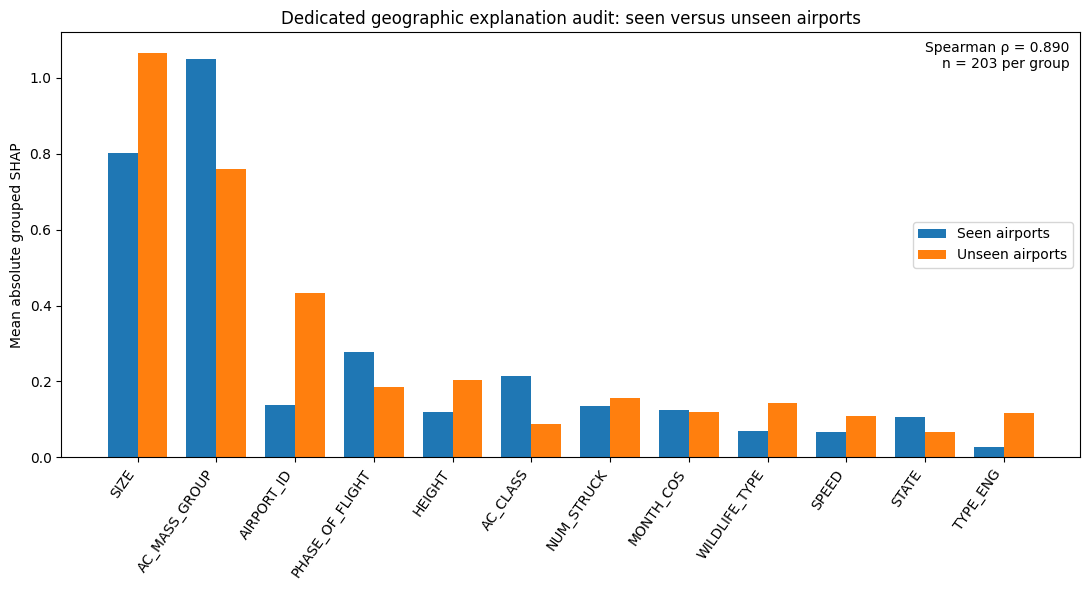

In [27]:
geo_compare = geo_status_importance_df.copy()

geo_compare["mean_importance"] = geo_compare[
    ["seen_airport", "unseen_airport"]
].mean(axis=1)

geo_top = (
    geo_compare
    .sort_values("mean_importance", ascending=False)
    .head(12)
)

x = np.arange(len(geo_top))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    x - width / 2,
    geo_top["seen_airport"],
    width,
    label="Seen airports",
)

ax.bar(
    x + width / 2,
    geo_top["unseen_airport"],
    width,
    label="Unseen airports",
)

ax.set_xticks(x)
ax.set_xticklabels(
    geo_top.index,
    rotation=55,
    ha="right",
)

ax.set_ylabel("Mean absolute grouped SHAP")

ax.set_title(
    "Dedicated geographic explanation audit: "
    "seen versus unseen airports"
)

ax.legend()

ax.text(
    0.99,
    0.98,
    f"Spearman ρ = {geo_rho:.3f}\n"
    f"n = {geo_n} per group",
    transform=ax.transAxes,
    ha="right",
    va="top",
)

plt.tight_layout()

fig.savefig(
    OUTPUT_DIR / "09_shap_dedicated_seen_vs_unseen_airports.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

In [28]:
# Bring Notebook 06's geographic validation evidence alongside the explanation audit.
geo_evidence_frames = []
for path in [GEO_DECISION_PATH, UNSEEN_METRICS_PATH]:
    if path.exists():
        temp = pd.read_csv(path)
        temp.insert(0, "source_artifact", path.name)
        geo_evidence_frames.append(temp)

if geo_evidence_frames:
    for frame in geo_evidence_frames:
        display(frame)

,source_artifact,selected_base_candidate,adequate_unseen_support,extended_dominates_unseen,extended_overall_within_1pct_relative_pr_auc,decision,final_test_used
0,geographic_model_decision.csv,xgboost__airport_aware,False,False,True,Retain Notebook-05 airport-aware XGBoost becau...,False


,source_artifact,definition,group,n,positives,prevalence,pr_auc,roc_auc,brier_score,log_loss,mean_predicted_probability,unique_airports,baseline_brier,brier_skill_score,calibration_in_the_large
0,final_test_unseen_airport_metrics.csv,unseen_to_base_training,False,58911,2169,0.036818,0.343885,0.880410,0.028343,0.111291,0.036774,1091,0.035463,0.200774,-0.000045
1,final_test_unseen_airport_metrics.csv,unseen_to_base_training,True,308,77,0.250000,0.749052,0.893012,0.106468,0.340457,0.221586,196,0.187500,0.432172,-0.028414
2,final_test_unseen_airport_metrics.csv,unseen_to_development,False,59016,2179,0.036922,0.345457,0.880675,0.028381,0.111393,0.036927,1122,0.035559,0.201855,0.000005
3,final_test_unseen_airport_metrics.csv,unseen_to_development,True,203,67,0.330049,0.766957,0.865397,0.135681,0.429552,0.272621,165,0.221117,0.386385,-0.057428


### Interpretation — is airport dependence excessive?

The natural-distribution evidence indicates that airport identity is useful but does not dominate the final binary damage model. `AIRPORT_ID` ranks sixth by grouped SHAP and accounts for approximately 3.8% of total grouped absolute attribution. It also ranks fifth under held-out permutation importance, where shuffling airport identity reduces PR-AUC by approximately 0.023. Wildlife size, aircraft mass, phase of flight, aircraft class, and number struck therefore remain substantial contributors to the model.

The original proportional 5,000-row SHAP sample contained only 17 observations from airports unseen during model development, which was insufficient for a stable geographic explanation comparison. A dedicated diagnostic comparison was therefore constructed using all 203 available unseen-airport final-test observations and an equally sized seeded sample of 203 seen-airport observations. This balancing was used only to compare explanation structure and does not replace the natural-distribution global importance estimates or model-performance metrics.

Using the corrected grouped-SHAP definition, the seen- and unseen-airport feature-importance rankings produced a Spearman correlation of **0.890**. This represents strong rank agreement: the model continues to rely on a broadly similar hierarchy of wildlife, aircraft, flight, and geographic information when evaluated at airports absent from model development. The exact attribution magnitudes are not identical, so the result should be interpreted as strong stability rather than equivalence.

The two geographic groups also differ substantially in outcome prevalence. Only 6 of the 203 sampled seen-airport observations reported damage (2.96%), compared with 67 of the 203 unseen-airport observations (33.0%). The dedicated analysis intentionally preserves the observed composition of each geographic group rather than matching their damage prevalence. Differences in SHAP magnitude can therefore reflect both geographic generalization and the broader distribution shift represented by the unseen-airport subset. The rank comparison is interpreted as a robustness check under geographic distribution shift rather than as an isolated causal test of airport status.

Notebook 06 provides complementary predictive evidence. For the stricter 203-observation unseen-to-development airport subset, the calibrated model achieved a PR-AUC of approximately 0.767 and ROC-AUC of approximately 0.865. These results are encouraging but should not be treated as proof of universal geographic generalization because the subset is small and unusually damage-rich.

Taken together, the evidence supports retaining the airport-aware model. Airport identity provides meaningful contextual information, but the model does not globally rely on airport identity alone, and its broader explanation ranking remains strongly similar under the unseen-airport evaluation. Predictions for genuinely unseen or historically sparse airports should nevertheless continue to carry an explicit historical-support warning in Notebook 10.

# 17. SHAP sampling stability check

In [29]:
shap_sample_2 = proportional_stratified_sample(test_df, SHAP_STABILITY_SAMPLE_N, SEED + 101)
X_shap_2 = preprocessor.transform(shap_sample_2[SELECTED_FEATURES])
shap_values_2 = explainer(X_shap_2)
values_2 = np.asarray(shap_values_2.values)
if values_2.ndim == 3 and values_2.shape[-1] == 2:
    values_2 = values_2[:, :, 1]

grouped_abs_2 = {}
for source in source_order:
    cols = np.where(source_names == source)[0]
    grouped_abs_2[source] = np.abs(values_2[:, cols].sum(axis=1)).mean()

stability = pd.DataFrame({
    "feature": source_order,
    "sample_1_mean_abs_shap": [grouped_abs_df[c].mean() for c in source_order],
    "sample_2_mean_abs_shap": [grouped_abs_2[c] for c in source_order],
})
stability["sample_1_rank"] = stability["sample_1_mean_abs_shap"].rank(ascending=False, method="average")
stability["sample_2_rank"] = stability["sample_2_mean_abs_shap"].rank(ascending=False, method="average")

rho, p = spearmanr(stability["sample_1_rank"], stability["sample_2_rank"])
stability_summary = pd.DataFrame([{
    "sample_1_rows": len(shap_sample),
    "sample_2_rows": len(shap_sample_2),
    "spearman_rank_correlation": rho,
    "p_value_descriptive_only": p,
}])

display(stability.sort_values("sample_1_rank"))
display(stability_summary)
stability.to_csv(OUTPUT_DIR / "09_shap_sampling_stability_features.csv", index=False)
stability_summary.to_csv(OUTPUT_DIR / "09_shap_sampling_stability_summary.csv", index=False)

,feature,sample_1_mean_abs_shap,sample_2_mean_abs_shap,sample_1_rank,sample_2_rank
7,AC_MASS_GROUP,1.135927,1.123254,1.0,1.0
4,SIZE,0.810233,0.813141,2.0,2.0
11,PHASE_OF_FLIGHT,0.286234,0.280964,3.0,3.0
6,AC_CLASS,0.240144,0.237390,4.0,4.0
5,NUM_STRUCK,0.135705,0.134766,5.0,5.0
19,AIRPORT_ID,0.132452,0.129152,6.0,6.0
2,MONTH_COS,0.123956,0.124223,7.0,7.0
12,HEIGHT,0.112291,0.110177,8.0,8.0
17,STATE,0.098940,0.100871,9.0,9.0
3,WILDLIFE_TYPE,0.070410,0.068857,10.0,10.0


,sample_1_rows,sample_2_rows,spearman_rank_correlation,p_value_descriptive_only
0,5000,5000,1.0,0.0


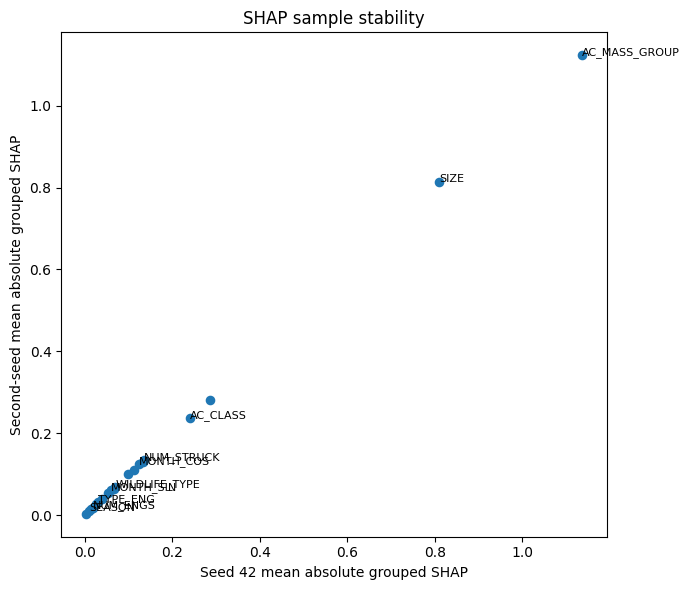

In [30]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(stability["sample_1_mean_abs_shap"], stability["sample_2_mean_abs_shap"], s=35)
for _, row in stability.head(10).iterrows():
    ax.annotate(
        row["feature"],
        (row["sample_1_mean_abs_shap"], row["sample_2_mean_abs_shap"]),
        fontsize=8,
    )
ax.set_xlabel("Seed 42 mean absolute grouped SHAP")
ax.set_ylabel("Second-seed mean absolute grouped SHAP")
ax.set_title("SHAP sample stability")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_shap_sampling_stability.png", dpi=160, bbox_inches="tight")
plt.show()

### Interpretation — computational sample adequacy

The computational SHAP subsampling strategy was highly stable. Two independent 5,000-row stratified samples produced identical rankings for all 20 grouped original features, giving a Spearman rank correlation of 1.000. Attribution magnitudes were also very similar between samples—for example, aircraft mass was 1.136 versus 1.123 and wildlife size 0.810 versus 0.813.

This result supports retaining the 5,000-row SHAP sample as a computationally efficient approximation for global explanation. Running TreeSHAP across all 59,219 final-test records would add substantial computation without evidence that it would materially change the global ranking used for interpretation.

# 18. Formal comparison with Notebook 04

In [31]:
# Merge the carried-forward Notebook 04 diagnostic refresh with
# the two global explainability rankings.
alignment = diagnostic_refresh.copy()

alignment = alignment.merge(
    grouped_importance[["feature", "rank", "mean_abs_grouped_shap"]].rename(
        columns={
            "rank": "SHAP_rank",
            "mean_abs_grouped_shap": "SHAP_mean_abs",
        }
    ),
    left_on="factor",
    right_on="feature",
    how="left",
).drop(columns="feature")

alignment = alignment.merge(
    perm_df[["feature", "rank", "importance_mean_pr_auc_drop"]].rename(
        columns={
            "rank": "permutation_rank",
            "importance_mean_pr_auc_drop": "permutation_PR_AUC_drop",
        }
    ),
    left_on="factor",
    right_on="feature",
    how="left",
).drop(columns="feature")


def classify_explainability_alignment(row):
    factor = row["factor"]

    if factor in ["SIZE", "AC_MASS_GROUP", "PHASE_OF_FLIGHT"]:
        return (
            "Strong alignment: Notebook 04 identified a meaningful association "
            "and the final multivariable model also assigns high predictive importance."
        )

    if factor == "NUM_STRUCK":
        return (
            "Broad alignment: Notebook 04 found a smaller association and the "
            "final model retains useful but secondary predictive contribution."
        )

    if factor == "WARNED":
        return (
            "Partial divergence: Notebook 04 identified an association, but the "
            "final model assigns little unique importance after other predictors "
            "are considered. Redundancy and conditional relationships are plausible."
        )

    if "×" in factor:
        return (
            "Interaction was assessed in Notebook 04. The grouped global rankings "
            "do not provide a separate interaction rank; inspect SHAP dependence "
            "patterns rather than treating the missing rank as disagreement."
        )

    return (
        "Compare the diagnostic association with multivariable model importance; "
        "differences may reflect redundancy, nonlinearity, or interactions."
    )


alignment["agreement_interpretation"] = alignment.apply(
    classify_explainability_alignment,
    axis=1,
)

display(alignment)

alignment.to_csv(
    OUTPUT_DIR / "09_notebook04_explainability_alignment.csv",
    index=False,
)


,factor,Notebook_04_refresh,Notebook_09_question,SHAP_rank,SHAP_mean_abs,permutation_rank,permutation_PR_AUC_drop,agreement_interpretation
0,SIZE,Strong association,Direction/importance should be inspected expli...,2.0,0.810233,1.0,0.220183,Strong alignment: Notebook 04 identified a mea...
1,AC_MASS_GROUP,Substantial association,Direction/importance should be inspected expli...,1.0,1.135927,2.0,0.088840,Strong alignment: Notebook 04 identified a mea...
2,PHASE_OF_FLIGHT,Meaningful group differences,Inspect category-specific SHAP behaviour,3.0,0.286234,4.0,0.024533,Strong alignment: Notebook 04 identified a mea...
3,NUM_STRUCK,Associated; smaller marginal signal than stron...,Check whether nonlinear/context interactions i...,5.0,0.135705,7.0,0.016202,Broad alignment: Notebook 04 found a smaller a...
4,WARNED,Formally assessed in diagnostic stage,Interpret cautiously; not a causal interventio...,16.0,0.026261,20.0,-0.000949,Partial divergence: Notebook 04 identified an ...
5,SIZE × AC_MASS_GROUP,Interaction examined,Look for context-dependent SHAP patterns,NaN,NaN,NaN,NaN,Interaction was assessed in Notebook 04. The g...
6,SIZE × PHASE_OF_FLIGHT,Interaction examined,Look for context-dependent SHAP patterns,NaN,NaN,NaN,NaN,Interaction was assessed in Notebook 04. The g...


### Interpretation — agreement and disagreement

The model explanations broadly align with the independent diagnostic evidence from Notebook 04. Wildlife size, aircraft mass, and phase of flight were among the strongest diagnostic associations and are also among the highest-ranked predictors under both grouped SHAP and permutation importance. `NUM_STRUCK`, which had a smaller diagnostic association, remains useful but ranks below the dominant size, mass, and phase factors.

`WARNED` shows the clearest difference: Notebook 04 detected an association, whereas it contributes very little unique predictive information in the final XGBoost model. This is not necessarily contradictory. The diagnostic analysis measures association, whereas permutation importance and SHAP assess how the fitted multivariable model uses information in the presence of other predictors. Warning status may overlap with flight phase, airport conditions, wildlife context, or other variables, leaving little unique predictive information after those factors are included.

Overall, the strongest model drivers correspond closely to the strongest independently observed associations, increasing the substantive plausibility of the fitted system.

# 19. Final leakage sanity check

In [32]:
FORBIDDEN_PATTERNS = [
    "DAMAGE_LEVEL", "DAM_", "COST", "INJUR", "FATAL",
    "EFFECT", "INGEST", "INGESTED", "REMARK", "NARRATIVE",
]

leakage_flags = []
for feature in SELECTED_FEATURES:
    upper = feature.upper()
    hits = [p for p in FORBIDDEN_PATTERNS if p in upper]
    leakage_flags.append({
        "feature": feature,
        "pattern_hits": " | ".join(hits),
        "flagged": bool(hits),
    })

leakage_audit = pd.DataFrame(leakage_flags)
display(leakage_audit)
leakage_audit.to_csv(OUTPUT_DIR / "09_final_feature_leakage_sanity_check.csv", index=False)

assert not leakage_audit["flagged"].any(), (
    "A final binary-model input matches a post-event/leakage pattern. Stop and investigate."
)

,feature,pattern_hits,flagged
0,SEASON,,False
1,MONTH_SIN,,False
2,MONTH_COS,,False
3,WILDLIFE_TYPE,,False
4,SIZE,,False
5,NUM_STRUCK,,False
6,AC_CLASS,,False
7,AC_MASS_GROUP,,False
8,TYPE_ENG,,False
9,NUM_ENGS,,False


In [33]:
# Explanation-based concentration check: no single variable is automatically leakage,
# but unexpected dominance is a reason to inspect its provenance and scenario availability.
concentration = grouped_importance[[
    "feature", "rank", "share_of_total_mean_abs_shap"
]].copy()
concentration["cumulative_share"] = concentration["share_of_total_mean_abs_shap"].cumsum()

display(concentration.head(15))
concentration.to_csv(OUTPUT_DIR / "09_explanation_concentration_check.csv", index=False)

,feature,rank,share_of_total_mean_abs_shap,cumulative_share
0,AC_MASS_GROUP,1,0.327067,0.327067
1,SIZE,2,0.233290,0.560357
2,PHASE_OF_FLIGHT,3,0.082415,0.642772
3,AC_CLASS,4,0.069145,0.711917
4,NUM_STRUCK,5,0.039073,0.750990
5,AIRPORT_ID,6,0.038137,0.789127
6,MONTH_COS,7,0.035691,0.824818
7,HEIGHT,8,0.032332,0.857150
8,STATE,9,0.028488,0.885638
9,WILDLIFE_TYPE,10,0.020273,0.905911


### Interpretation — leakage sanity

The final leakage audit found no predictor name matching known post-event outcome, damage-component, cost, injury, fatality, or operational-consequence patterns. All 20 predictors therefore remain consistent with the scenario-eligible feature set established upstream.

The attribution profile also does not show an unexplained administrative identifier dominating the model. The two largest contributors are aircraft mass and wildlife size, followed by flight and aircraft context. `AIRPORT_ID` is important but represents only approximately 3.8% of grouped SHAP attribution.

The main feature-provenance caution concerns missing/unknown categories, particularly `AC_MASS_GROUP = Unknown` and `PHASE_OF_FLIGHT = Not reported`, which receive noticeable SHAP contributions. Earlier data-quality analysis established that documentation completeness differs across records, so these categories can encode reporting patterns. They are not direct outcome leakage, but the model's use of them should be disclosed as a limitation.

No explainability result currently provides evidence requiring removal of a predictor or retraining before simulation.

# 20. Representative local explanations: TP, TN, FP, FN

The local cases are defined using the same **locked maximum-validation-F1 threshold** shown in the confusion matrix. Therefore there is no conflict between the confusion matrix and the local explanations: both use the same binary decision rule.

Within each confusion-matrix cell, the representative record is the observation whose calibrated probability is closest to that cell's median calibrated probability. This is more reproducible and less arbitrary than taking the first record encountered.

In [34]:
case_frame = test_df[["INDEX_NR", "INCIDENT_YEAR", TARGET, "AIRPORT_SEEN_STATUS"] + SELECTED_FEATURES].copy()
case_frame["calibrated_probability"] = final_probability
case_frame["raw_probability"] = raw_probability
case_frame["locked_prediction"] = locked_prediction
case_frame["case_type"] = np.select(
    [
        (case_frame[TARGET].eq(1) & case_frame["locked_prediction"].eq(1)),
        (case_frame[TARGET].eq(0) & case_frame["locked_prediction"].eq(0)),
        (case_frame[TARGET].eq(0) & case_frame["locked_prediction"].eq(1)),
        (case_frame[TARGET].eq(1) & case_frame["locked_prediction"].eq(0)),
    ],
    ["true_positive", "true_negative", "false_positive", "false_negative"],
    default="unknown",
)

def choose_representative(group):
    median_p = group["calibrated_probability"].median()
    return group.loc[(group["calibrated_probability"] - median_p).abs().idxmin()]

representative_rows = []
for case_type in ["true_positive", "true_negative", "false_positive", "false_negative"]:
    group = case_frame.loc[case_frame["case_type"].eq(case_type)]
    if len(group):
        row = choose_representative(group).copy()
        representative_rows.append(row)

representative_cases = pd.DataFrame(representative_rows).reset_index(drop=True)
display(representative_cases[[
    "case_type", "INDEX_NR", "INCIDENT_YEAR", TARGET,
    "calibrated_probability", "raw_probability", "AIRPORT_SEEN_STATUS"
]])
representative_cases.to_csv(OUTPUT_DIR / "09_representative_local_cases.csv", index=False)

,case_type,INDEX_NR,INCIDENT_YEAR,INDICATED_DAMAGE,calibrated_probability,raw_probability,AIRPORT_SEEN_STATUS
0,true_positive,1353953,2022,1,0.466667,0.526129,seen_airport
1,true_negative,1171521,2022,0,0.013706,0.020239,seen_airport
2,false_positive,1185098,2022,0,0.276630,0.291817,seen_airport
3,false_negative,1241741,2022,1,0.047250,0.071035,seen_airport


In [35]:
# Compute SHAP for the four representative cases using the raw XGBoost model.
local_X_original = representative_cases[SELECTED_FEATURES]
local_X_transformed = preprocessor.transform(local_X_original)
local_shap = explainer(local_X_transformed)
local_values = np.asarray(local_shap.values)
if local_values.ndim == 3 and local_values.shape[-1] == 2:
    local_values = local_values[:, :, 1]

local_grouped_rows = []
for row_pos, case in representative_cases.iterrows():
    contributions = {}
    for source in source_order:
        cols = np.where(source_names == source)[0]
        contributions[source] = float(local_values[row_pos, cols].sum())

    ranked = sorted(contributions.items(), key=lambda kv: abs(kv[1]), reverse=True)
    for rank, (feature, contribution) in enumerate(ranked, start=1):
        local_grouped_rows.append({
            "case_type": case["case_type"],
            "INDEX_NR": case["INDEX_NR"],
            "feature": feature,
            "grouped_shap_raw_log_odds": contribution,
            "abs_grouped_shap": abs(contribution),
            "rank": rank,
            "original_value": case[feature],
        })

local_grouped = pd.DataFrame(local_grouped_rows)
local_grouped.to_csv(OUTPUT_DIR / "09_local_grouped_shap_explanations.csv", index=False)
display(local_grouped.query("rank <= 10"))

,case_type,INDEX_NR,feature,grouped_shap_raw_log_odds,abs_grouped_shap,rank,original_value
0,true_positive,1353953,SIZE,1.744184,1.744184,1,Large
1,true_positive,1353953,AC_MASS_GROUP,0.816648,0.816648,2,Light
2,true_positive,1353953,TYPE_ENG,0.196791,0.196791,3,A
3,true_positive,1353953,WARNED,-0.177872,0.177872,4,Yes
4,true_positive,1353953,HEIGHT,0.174619,0.174619,5,500.0
5,true_positive,1353953,MONTH_COS,-0.091133,0.091133,6,-0.0
6,true_positive,1353953,NUM_STRUCK,-0.085021,0.085021,7,1
7,true_positive,1353953,SPEED,0.071813,0.071813,8,70.0
8,true_positive,1353953,TIME_OF_DAY,0.070761,0.070761,9,Day
9,true_positive,1353953,AIRPORT_ID,-0.066164,0.066164,10,KAPC


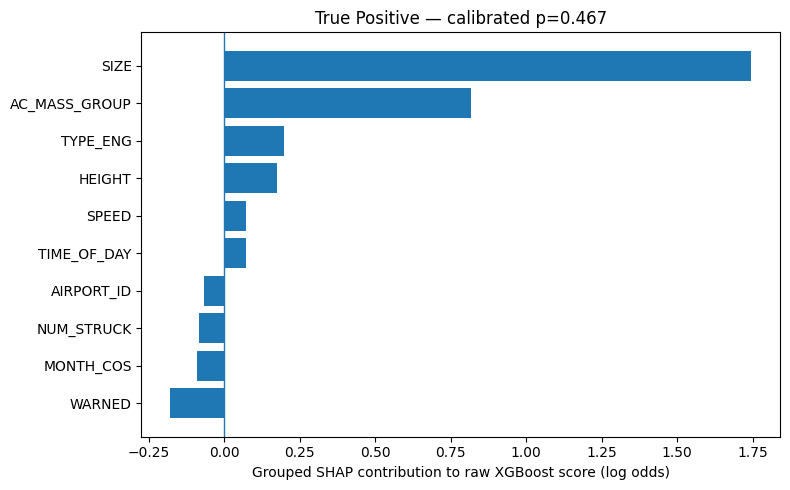

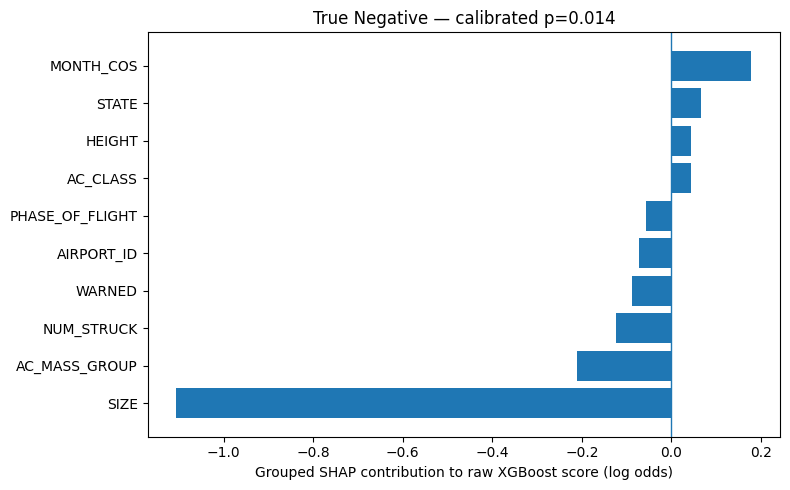

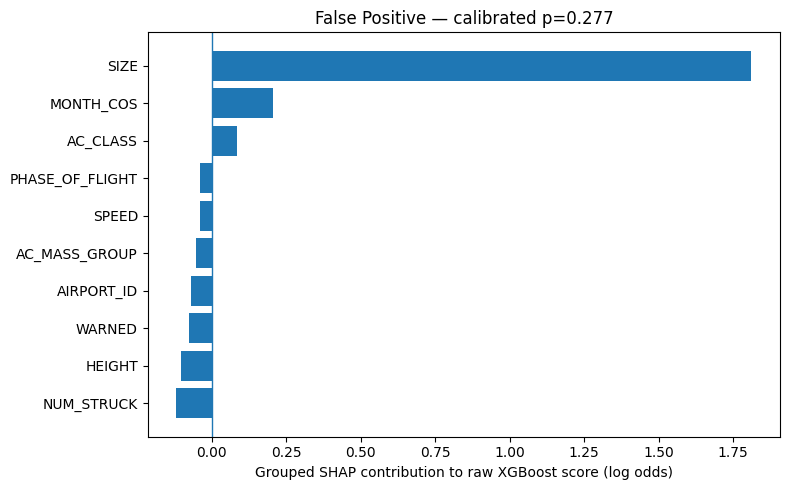

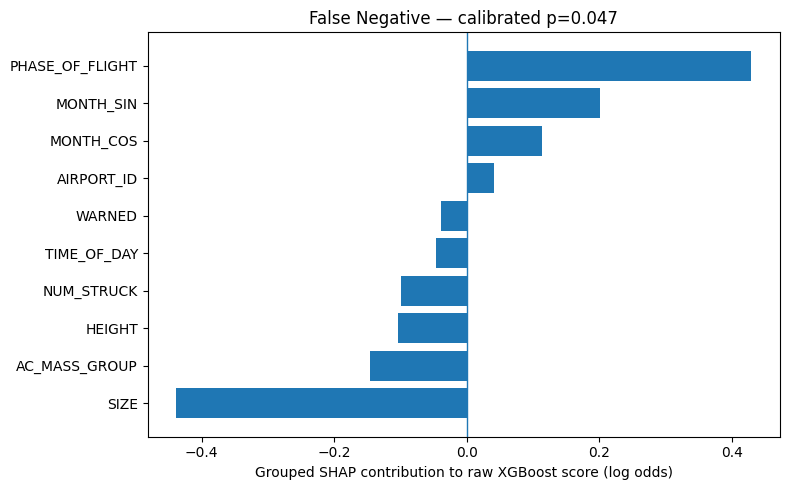

In [36]:
for case_type in representative_cases["case_type"]:
    case_meta = representative_cases.loc[representative_cases["case_type"].eq(case_type)].iloc[0]
    top = (
        local_grouped.loc[local_grouped["case_type"].eq(case_type)]
        .sort_values("abs_grouped_shap", ascending=False)
        .head(10)
        .sort_values("grouped_shap_raw_log_odds")
    )

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(top["feature"], top["grouped_shap_raw_log_odds"])
    ax.axvline(0, linewidth=1)
    ax.set_xlabel("Grouped SHAP contribution to raw XGBoost score (log odds)")
    ax.set_title(
        f"{case_type.replace('_', ' ').title()} — calibrated p={case_meta['calibrated_probability']:.3f}"
    )
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f"09_local_{case_type}_shap.png", dpi=160, bbox_inches="tight")
    plt.show()

### Interpretation — local cases

The four representative records use the same locked threshold of **0.20** that is used in the confusion-matrix summary. They were selected near the median calibrated probability within each TP/TN/FP/FN class so that the examples are representative rather than extreme cases. All four examples shown here are from airports seen during model development.

- **Representative true positive:** calibrated damage probability = **0.467**. Large wildlife is the strongest positive contributor (+1.744 raw log-odds SHAP), followed by the Light aircraft-mass category (+0.817). Warning status and several smaller factors pull in the opposite direction. The reported outcome was damage, so the model correctly classified this scenario above the locked threshold.
- **Representative true negative:** calibrated damage probability = **0.0137**. Small wildlife is the dominant negative contributor (-1.106), with additional negative contributions from aircraft-mass context, one animal struck, warning status, airport, and approach phase. The low probability is consistent with the reported no-damage outcome.
- **Representative false positive:** calibrated damage probability = **0.277**. Large wildlife provides a very strong positive contribution (+1.810), large enough to outweigh several smaller negative contributions. The reported outcome was nevertheless no damage. This illustrates that a strong historical risk signal can increase predicted probability without determining the outcome of an individual strike.
- **Representative false negative:** calibrated damage probability = **0.0473**. Climb phase pushes the raw score upward (+0.430), but the unreported wildlife-size category (-0.438), aircraft-mass context, height, and the single-animal category pull it downward. Damage was reported despite the low model probability, illustrating how missing key scenario information and several lower-risk historical signals can contribute to underestimation.

These contributions explain movement in the **raw XGBoost log-odds score**, not percentage-point changes in the final isotonic-calibrated probability. The examples explain model behaviour, not the physical cause of the observed damage.


# 21. Optional: individual transformed-feature waterfall plots

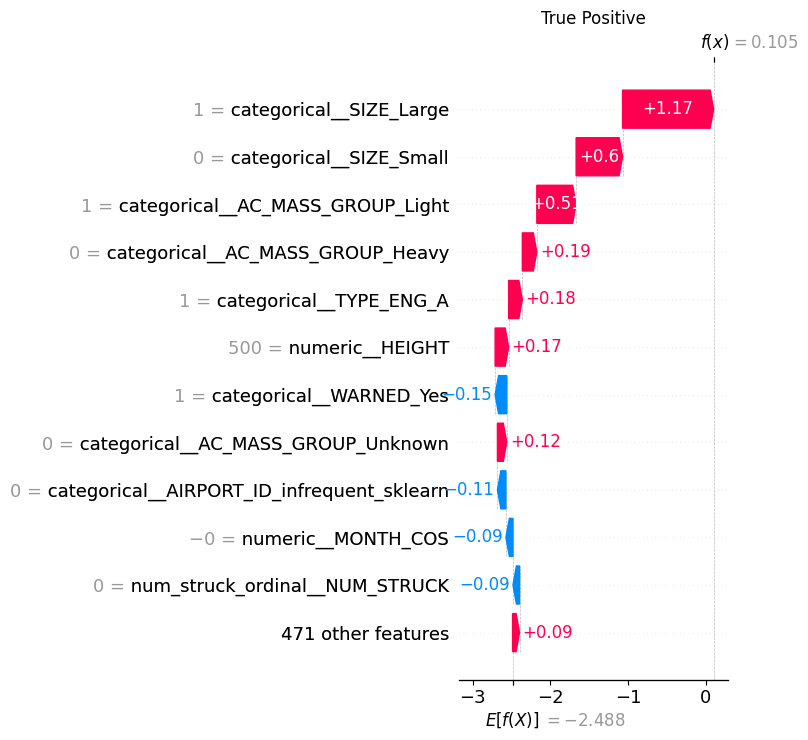

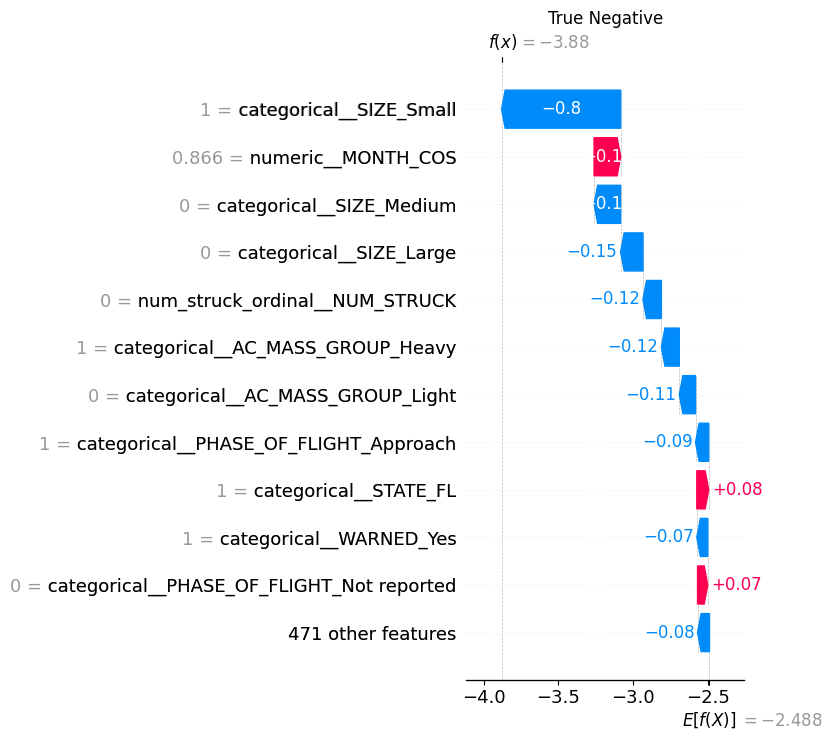

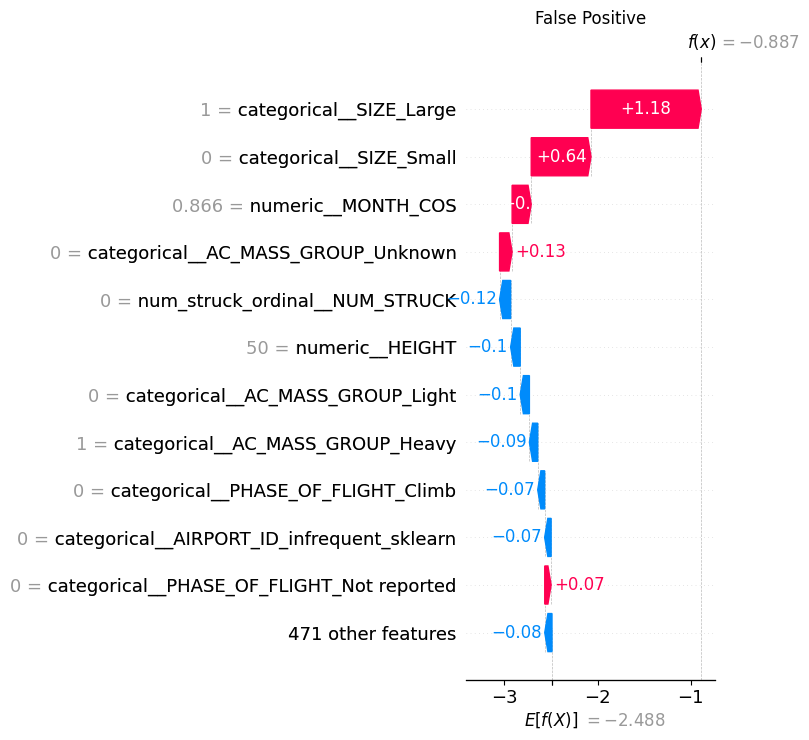

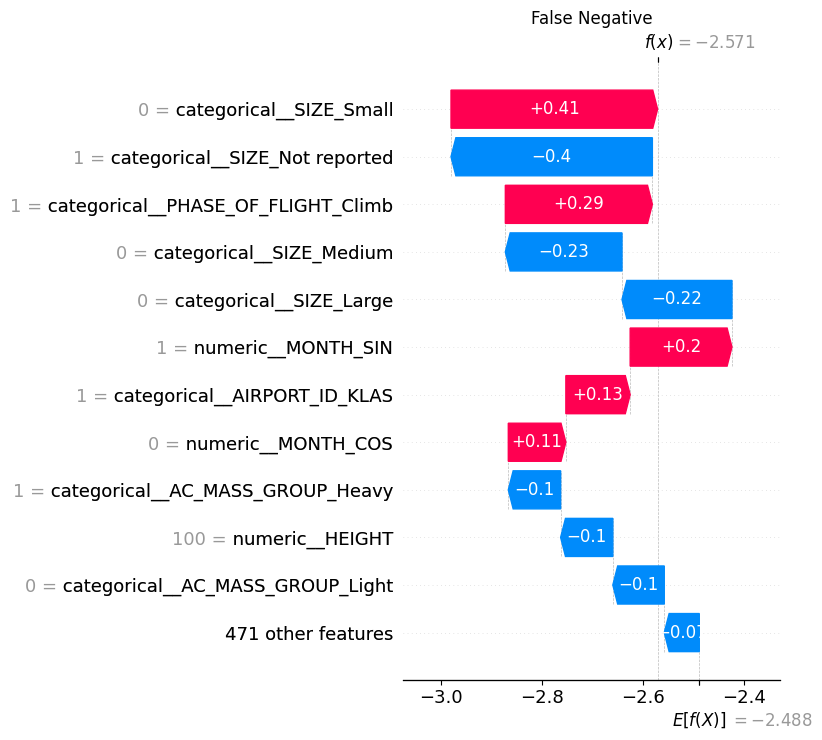

In [37]:
# Waterfall plots preserve the exact transformed-feature decomposition.
# They are optional storytelling figures because the grouped local plots above
# are easier to communicate in terms of original scenario inputs.

for row_pos, case in representative_cases.iterrows():
    try:
        explanation = shap.Explanation(
            values=local_values[row_pos],
            base_values=(
                local_shap.base_values[row_pos]
                if np.ndim(local_shap.base_values) else local_shap.base_values
            ),
            data=(
                local_X_transformed[row_pos].toarray().ravel()
                if hasattr(local_X_transformed[row_pos], "toarray")
                else np.asarray(local_X_transformed[row_pos]).ravel()
            ),
            feature_names=transformed_feature_names,
        )
        shap.plots.waterfall(explanation, max_display=12, show=False)
        plt.title(case["case_type"].replace("_", " ").title())
        plt.tight_layout()
        plt.savefig(
            OUTPUT_DIR / f"09_local_{case['case_type']}_waterfall_transformed.png",
            dpi=160,
            bbox_inches="tight",
        )
        plt.show()
    except Exception as exc:
        warnings.warn(f"Waterfall plot skipped for {case['case_type']}: {exc}")

# 22. Secondary-model explainability status: severity and components

The primary binary damage model receives the complete SHAP/stability audit because it is the project's principal calibrated probability system. The secondary models remain important but are conditional on damage or other downstream outcomes and passed separate decision gates.

This section therefore does two things:

1. **always** reports which secondary systems were retained and what their conditional targets mean;
2. provides an **optional lightweight permutation-importance audit** (`RUN_SECONDARY_EXPLAINABILITY = True`) for retained models when additional runtime is available.

This avoids silently neglecting the secondary models while keeping computational effort proportional to their role in the project.

In [38]:
secondary_status_rows = []

# ---------------------------------------------------------------------
# Severity system — locate Notebook 07 decision metadata.
# Notebook 09 reports the upstream decision rather than redefining it.
# ---------------------------------------------------------------------

severity_decision_candidates = [
    NB07_OUTPUT_DIR / "severity_decision.json",
    NB07_OUTPUT_DIR / "07_severity_decision.json",
    NB07_OUTPUT_DIR / "severity_model_decision.json",
    NB07_OUTPUT_DIR / "07_severity_model_decision.json",
]

severity_decision_path = next(
    (p for p in severity_decision_candidates if p.exists()),
    None,
)

if severity_decision_path is None and NB07_OUTPUT_DIR.exists():
    decision_like = sorted(
        p for p in NB07_OUTPUT_DIR.glob("*.json")
        if "decision" in p.name.lower()
    )

    if decision_like:
        severity_decision_path = decision_like[0]

severity_final_candidates = [
    NB07_FINAL_DIR / "final_known_severity_probability_system.joblib",
    NB07_FINAL_DIR / "final_severity_probability_system.joblib",
    NB07_FINAL_DIR / "final_severity_model.joblib",
]

severity_final_path = next(
    (p for p in severity_final_candidates if p.exists()),
    None,
)

if severity_final_path is None and NB07_FINAL_DIR.exists():
    final_like = sorted(
        NB07_FINAL_DIR.glob("*.joblib")
    )

    if final_like:
        severity_final_path = final_like[0]

if severity_decision_path is not None:

    with open(
        severity_decision_path,
        "r",
        encoding="utf-8"
    ) as f:
        sev = json.load(f)

    severity_decision = (
        sev.get("decision")
        or sev.get("final_decision")
        or sev.get("severity_decision")
        or "Decision metadata found; decision key not recognized"
    )

    severity_model_exported = bool(
        sev.get(
            "final_model_exported",
            severity_final_path is not None,
        )
    )

    severity_artifact = (
        sev.get("final_model_path")
        or sev.get("artifact")
        or (
            str(severity_final_path)
            if severity_final_path is not None
            else None
        )
    )

    secondary_status_rows.append({
        "system": "severity",
        "target": "Known severity: S+D versus M",
        "decision": severity_decision,
        "model_exported": severity_model_exported,
        "conditional_population":
            "Reported strike + reported damage + DAMAGE_LEVEL in {M, S, D}; ambiguous/unknown severity codes excluded",
        "artifact": severity_artifact,
        "decision_source": severity_decision_path.name,
    })

else:

    secondary_status_rows.append({
        "system": "severity",
        "target": "Known severity: S+D versus M",
        "decision":
            "Notebook 07 decision metadata not located by Notebook 09",
        "model_exported":
            severity_final_path is not None,
        "conditional_population":
            "Reported strike + reported damage + known severity; see Notebook 07 gate",
        "artifact":
            str(severity_final_path)
            if severity_final_path is not None
            else None,
        "decision_source": None,
    })


# ---------------------------------------------------------------------
# Component systems — read Notebook 08's retained systems.
# ---------------------------------------------------------------------

component_manifest_path = (
    NB08_OUTPUT_DIR / "component_final_model_manifest.csv"
)

if component_manifest_path.exists():

    comp_manifest = pd.read_csv(
        component_manifest_path
    )

    for _, row in comp_manifest.iterrows():

        secondary_status_rows.append({
            "system": "component",
            "target": row.get("target"),
            "decision": row.get(
                "decision",
                "MODELLED"
            ),
            "model_exported": True,
            "conditional_population":
                "Reported strike + reported aircraft damage",
            "artifact": row.get(
                "artifact",
                row.get("path"),
            ),
            "decision_source":
                component_manifest_path.name,
        })

else:

    secondary_status_rows.append({
        "system": "component",
        "target": "Retained component targets",
        "decision":
            "Notebook 08 final-model manifest not located by Notebook 09",
        "model_exported": False,
        "conditional_population":
            "Reported strike + reported aircraft damage; see Notebook 08 gate",
        "artifact": None,
        "decision_source": None,
    })


secondary_status = pd.DataFrame(
    secondary_status_rows
)

display(secondary_status)

secondary_status.to_csv(
    OUTPUT_DIR / "09_secondary_model_status.csv",
    index=False,
)


,system,target,decision,model_exported,conditional_population,artifact,decision_source
0,severity,Known severity: S+D versus M,SIMPLIFY,True,Reported strike + reported damage + DAMAGE_LEV...,c:\Users\davis\Programing\MDA_programs\Capston...,severity_decision.json
1,component,ENGINE_DAMAGE,MODELLED,True,Reported strike + reported aircraft damage,c:\Users\davis\Programing\MDA_programs\Capston...,component_final_model_manifest.csv
2,component,WING_ROTOR_DAMAGE,MODELLED,True,Reported strike + reported aircraft damage,c:\Users\davis\Programing\MDA_programs\Capston...,component_final_model_manifest.csv
3,component,FORWARD_COCKPIT_DAMAGE,MODELLED,True,Reported strike + reported aircraft damage,c:\Users\davis\Programing\MDA_programs\Capston...,component_final_model_manifest.csv
4,component,LANDING_GEAR_DAMAGE,MODELLED,True,Reported strike + reported aircraft damage,c:\Users\davis\Programing\MDA_programs\Capston...,component_final_model_manifest.csv
5,component,PROPELLER_DAMAGE,MODELLED,True,Reported strike + reported aircraft damage,c:\Users\davis\Programing\MDA_programs\Capston...,component_final_model_manifest.csv


In [39]:
def component_target_from_sources(frame, source_fields):
    existing = [c for c in source_fields if c in frame.columns]
    if not existing:
        raise KeyError(f"None of the component source fields are present: {source_fields}")
    numeric = frame[existing].apply(pd.to_numeric, errors="coerce").fillna(0)
    return numeric.max(axis=1).astype(int)

secondary_perm_rows = []

if RUN_SECONDARY_EXPLAINABILITY:
    print("Running optional secondary-model permutation importance...")

    # ---- Severity ----
    sev_path = NB07_FINAL_DIR / "final_known_severity_probability_system.joblib"
    if sev_path.exists() and "DAMAGE_LEVEL" in df.columns:
        artifact = joblib.load(sev_path)
        features = artifact["features"]
        base = artifact["base_pipeline"]

        sev_test = df.loc[
            test_mask
            & df["INDICATED_DAMAGE"].eq(1)
            & df["DAMAGE_LEVEL"].isin(["M", "S", "D"])
        ].copy()
        sev_test["_target"] = sev_test["DAMAGE_LEVEL"].isin(["S", "D"]).astype(int)
        if len(sev_test) and sev_test["_target"].nunique() == 2:
            sample = sev_test.sample(n=min(SECONDARY_SAMPLE_N, len(sev_test)), random_state=SEED)
            result = permutation_importance(
                base, sample[features], sample["_target"],
                scoring="average_precision",
                n_repeats=SECONDARY_PERMUTATION_REPEATS,
                random_state=SEED,
                n_jobs=-1,
            )
            for feat, mean, std in zip(features, result.importances_mean, result.importances_std):
                secondary_perm_rows.append({
                    "system": "severity", "target": "S+D_vs_M", "feature": feat,
                    "importance_mean_pr_auc_drop": mean, "importance_std": std,
                })

    # ---- Components ----
    for artifact_path in sorted(NB08_FINAL_DIR.glob("*.joblib")):
        try:
            artifact = joblib.load(artifact_path)
            if not isinstance(artifact, dict) or "base_pipeline" not in artifact or "target" not in artifact:
                continue
            target = artifact["target"]
            features = artifact["features"]
            sources = artifact.get("target_source_fields", [target])
            base = artifact["base_pipeline"]

            comp_test = df.loc[test_mask & df["INDICATED_DAMAGE"].eq(1)].copy()
            comp_test["_target"] = component_target_from_sources(comp_test, sources)
            if len(comp_test) == 0 or comp_test["_target"].nunique() < 2:
                continue
            sample = comp_test.sample(n=min(SECONDARY_SAMPLE_N, len(comp_test)), random_state=SEED)
            result = permutation_importance(
                base, sample[features], sample["_target"],
                scoring="average_precision",
                n_repeats=SECONDARY_PERMUTATION_REPEATS,
                random_state=SEED,
                n_jobs=-1,
            )
            for feat, mean, std in zip(features, result.importances_mean, result.importances_std):
                secondary_perm_rows.append({
                    "system": "component", "target": target, "feature": feat,
                    "importance_mean_pr_auc_drop": mean, "importance_std": std,
                })
        except Exception as exc:
            warnings.warn(f"Skipped {artifact_path.name}: {exc}")

secondary_perm = pd.DataFrame(secondary_perm_rows)
if len(secondary_perm):
    secondary_perm["rank_within_target"] = (
        secondary_perm.groupby(["system", "target"])["importance_mean_pr_auc_drop"]
        .rank(ascending=False, method="first")
    )
    display(secondary_perm.sort_values(["system", "target", "rank_within_target"]))
    secondary_perm.to_csv(OUTPUT_DIR / "09_secondary_model_permutation_importance.csv", index=False)
else:
    print(
        "Secondary permutation audit not run. Set RUN_SECONDARY_EXPLAINABILITY = True "
        "if runtime permits and all Notebook 07/08 final artifacts are available."
    )

Secondary permutation audit not run. Set RUN_SECONDARY_EXPLAINABILITY = True if runtime permits and all Notebook 07/08 final artifacts are available.


### Interpretation — secondary systems

The full explainability audit remains centered on the primary binary damage-probability model because it is the project's first and principal calibrated probability system.

Notebook 07 is now located correctly under `07_severity_modelling`. Its decision metadata reports **SIMPLIFY**, and a final severity artifact is present. The retained severity task is therefore the simplified binary comparison **S + D versus M**, conditional on a reported strike with reported aircraft damage and usable severity information. Notebook 09 does not reinterpret this as an unconditional severity probability.

Notebook 08 retains five conditional component systems: engine damage, wing/rotor damage, forward-cockpit damage, landing-gear damage, and propeller damage. These component models are also downstream of the primary damage event and must not be interpreted as unconditional component-damage probabilities for every wildlife strike.

The optional secondary permutation-importance audit remains disabled in this run to prioritize the primary model's SHAP, stability, geographic, leakage, and local-error analyses and to limit additional computation. This does not reverse the upstream Notebook 07 or Notebook 08 decision gates; it means only that Notebook 09 gives the secondary systems a lighter explainability treatment.


# 23. Consolidated explainability evidence table

In [40]:
summary = grouped_importance[[
    "feature",
    "rank",
    "mean_abs_grouped_shap",
    "share_of_total_mean_abs_shap",
]].rename(columns={"rank": "shap_rank"})

summary = summary.merge(
    perm_df[[
        "feature",
        "rank",
        "importance_mean_pr_auc_drop",
    ]].rename(
        columns={"rank": "permutation_rank"}
    ),
    on="feature",
    how="outer",
)

summary["research_priority"] = summary["feature"].isin(PRIORITY_FEATURES)


def consolidated_interpretation(row):
    shap_rank = row.get("shap_rank")
    perm_rank = row.get("permutation_rank")
    feature = row["feature"]

    if feature in ["AC_MASS_GROUP", "SIZE"]:
        return "Dominant driver; high importance under both SHAP and permutation analysis."

    if feature == "PHASE_OF_FLIGHT":
        return "Major contextual driver; high global importance with category-specific direction."

    if feature == "NUM_STRUCK":
        return "Meaningful secondary research-question driver with coherent directional evidence."

    if feature == "AIRPORT_ID":
        return "Useful geographic context; important but not dominant in the natural-distribution audit."

    if feature in ["MONTH_SIN", "MONTH_COS", "SEASON", "TIME_OF_DAY"]:
        return "Temporal context; contribution is smaller than the dominant wildlife/aircraft factors."

    if feature in ["STATE", "FAAREGION"]:
        return "Geographic context; interpret jointly with airport-held-out validation."

    if feature == "WARNED":
        return "Low unique predictive importance despite diagnostic association; redundancy is plausible."

    if pd.notna(shap_rank) and shap_rank <= 10:
        return "Moderate supporting predictor in the fitted multivariable model."

    return "Lower global importance; may still contribute through interactions or specific scenarios."


summary["interpretation"] = summary.apply(
    consolidated_interpretation,
    axis=1,
)

summary = summary.sort_values(
    ["shap_rank", "permutation_rank"],
    na_position="last",
)

display(summary)

summary.to_csv(
    OUTPUT_DIR / "09_consolidated_explainability_evidence.csv",
    index=False,
)


,feature,shap_rank,mean_abs_grouped_shap,share_of_total_mean_abs_shap,permutation_rank,importance_mean_pr_auc_drop,research_priority,interpretation
1,AC_MASS_GROUP,1,1.135927,0.327067,2,0.088840,True,Dominant driver; high importance under both SH...
12,SIZE,2,0.810233,0.233290,1,0.220183,True,Dominant driver; high importance under both SH...
9,PHASE_OF_FLIGHT,3,0.286234,0.082415,4,0.024533,True,Major contextual driver; high global importanc...
0,AC_CLASS,4,0.240144,0.069145,12,0.006892,False,Moderate supporting predictor in the fitted mu...
8,NUM_STRUCK,5,0.135705,0.039073,7,0.016202,True,Meaningful secondary research-question driver ...
2,AIRPORT_ID,6,0.132452,0.038137,5,0.022565,True,Useful geographic context; important but not d...
5,MONTH_COS,7,0.123956,0.035691,10,0.010646,True,Temporal context; contribution is smaller than...
4,HEIGHT,8,0.112291,0.032332,3,0.037654,False,Moderate supporting predictor in the fitted mu...
15,STATE,9,0.098940,0.028488,14,0.006363,True,Geographic context; interpret jointly with air...
19,WILDLIFE_TYPE,10,0.070410,0.020273,6,0.019291,False,Moderate supporting predictor in the fitted mu...


# 24. Final interpretation and decision

## 24.1 What drives the binary damage model?

The final binary damage model relies primarily on aircraft and wildlife characteristics. `AC_MASS_GROUP` ranks first under grouped SHAP with 32.7% of total absolute attribution, while `SIZE` ranks second with 23.3%. Wildlife size is simultaneously the strongest permutation feature, reducing held-out PR-AUC by 0.220 when shuffled, with aircraft mass second at 0.089. Phase of flight, aircraft class, number struck, height, wildlife type, and airport provide additional predictive information.

Directional SHAP results are particularly clear for wildlife size and number struck: Large and Medium wildlife increase the raw model score on average while Small wildlife decreases it; strikes involving 2–10 animals increase the score compared with single-animal strikes. Phase of flight shows context-specific effects rather than a simple ordering. Aircraft mass is highly influential but has a nonlinear/context-dependent pattern and should not be reduced to a simple causal "heavier versus lighter" statement.

## 24.2 Are the explanations stable?

The explanation profile is strongly stable across temporal, computational-sampling, and geographic evaluations.

Across the locked 2022, 2023, and 2024 final-test years, pairwise Spearman correlations among grouped-SHAP feature rankings range from 0.998 to 1.000. The dominant variables also retain very similar attribution magnitudes across years, indicating that the model continues to rely on essentially the same information throughout the future-year evaluation period.

The computational SHAP sampling strategy is similarly stable. Two independent stratified samples of 5,000 final-test observations produced identical grouped-feature rankings, with a Spearman correlation of 1.000. This provides empirical support for using a computationally reduced SHAP sample rather than explaining all 59,219 final-test observations.

Geographic explanation stability was assessed separately using 203 observations from airports seen during development and all 203 available observations from airports unseen during development. Their grouped-SHAP rankings produced a Spearman correlation of **0.890**, indicating strong similarity in the hierarchy of features used by the model across the geographic holdout condition.

The geographic groups differ substantially in outcome prevalence, so the 0.890 result should be interpreted as robustness under a meaningful distribution shift rather than proof that seen and unseen airports are statistically equivalent. Overall, however, the evidence indicates that the model is not relying on a highly unstable or temporary set of predictors across future years, repeated SHAP samples, or the unseen-airport evaluation.

## 24.3 Is airport dependence acceptable?

The combined explainability and validation evidence supports retaining the airport-aware model, while continuing to treat geographic extrapolation as a support limitation.

Under the natural final-test distribution, `AIRPORT_ID` ranks sixth by grouped SHAP and accounts for approximately 3.8% of total grouped absolute attribution. It ranks fifth under permutation importance, where disrupting airport identity reduces PR-AUC by approximately 0.023. Airport identity therefore contributes useful information but is not the dominant source of model attribution; wildlife size, aircraft mass, phase of flight, and other aircraft/wildlife characteristics remain major contributors.

The dedicated geographic SHAP audit found strong agreement between the feature-importance rankings for seen and unseen airports, with a Spearman correlation of **0.890** across equal 203-observation comparison groups. This indicates that the model does not switch to an entirely different set of predictors when applied to airports absent from model development.

The magnitude of some contributions nevertheless changes across the two groups, including the contribution associated with airport identity itself. This is not unexpected because the unseen-airport subset represents a substantial distribution shift: its observed damage prevalence is approximately 33.0%, compared with approximately 3.0% in the matched-size seen-airport sample. The geographic SHAP comparison therefore evaluates model robustness under this shifted population rather than isolating a pure effect of airport-seen status.

Notebook 06 provides complementary predictive evidence, with PR-AUC of approximately 0.767 and ROC-AUC of approximately 0.865 in the stricter unseen-to-development airport subset. Because that subset contains only 203 observations and is unusually damage-rich, these results are encouraging rather than evidence of universal geographic generalization.

Overall, airport dependence is considered acceptable for the retained model. Airport identity acts as one contextual predictor among a broader set of wildlife, aircraft, flight, geographic, and temporal features. Notebook 10 should nevertheless flag unseen or historically sparse airports as lower-support scenarios.

## 24.4 Does the model broadly agree with Notebook 04?

The explainability results broadly agree with the independent diagnostic evidence established in Notebook 04.

Wildlife size, aircraft mass, and phase of flight were among the strongest diagnostic associations and also emerge among the most influential variables in the final nonlinear model. `SIZE` ranks second under grouped SHAP and first under permutation importance, while `AC_MASS_GROUP` ranks first and second respectively. `PHASE_OF_FLIGHT` also remains an important contributor under both explainability methods.

`NUM_STRUCK` shows a weaker but coherent relationship across notebooks. Notebook 04 found a smaller association than for wildlife size or aircraft mass, and Notebook 09 likewise places number struck below the dominant predictors while retaining a meaningful contribution.

`WARNED` provides the clearest partial disagreement. Warning status showed an observed association in Notebook 04 but contributes little unique predictive information in the final XGBoost model. This is not inherently contradictory because Notebook 04 evaluated association, whereas SHAP and permutation importance describe the behaviour of a multivariable nonlinear predictor after other information is available. Warning status may therefore overlap with information already represented by flight phase, airport, wildlife context, or other variables.

The interaction rows carried forward from Notebook 04 do not receive separate global SHAP ranks because Notebook 09 groups attributions to the original input variables. Their absence from the ranking is therefore not evidence of disagreement; nonlinear context dependence is inspected through SHAP direction/dependence views instead.

Overall, there is no major unexplained contradiction between the independent diagnostic analysis and the final model's explanation profile.

## 24.5 Final leakage sanity decision

No prohibited post-event outcome field appears in the final predictor set, and the attribution profile is dominated by scientifically plausible scenario characteristics rather than outcome-derived variables. Airport identity contributes but does not dominate. Missing/unknown categories do carry predictive information and therefore remain an explicit reporting-practice limitation, but the explainability audit does not identify evidence of direct target leakage requiring retraining.

## 24.6 Explainability gate for Notebook 10

**PASS WITH WARNINGS.**

The primary binary damage model passes the explainability gate for downstream Monte Carlo simulation. Its dominant explanations are substantively plausible, broadly consistent with the independent diagnostic evidence from Notebook 04, and strongly stable across future reporting years, repeated SHAP samples, and the dedicated geographic holdout analysis.

Aircraft mass and wildlife size are the dominant global explanatory factors, with meaningful additional contributions from phase of flight, aircraft class, number struck, geography, and temporal context. The directional behaviour of wildlife size and number struck is also broadly consistent with the project's research expectations. No prohibited post-event leakage variable was identified, and airport identity does not dominate the natural-distribution global explanation profile.

The dedicated seen-versus-unseen airport comparison produced strong feature-ranking agreement (Spearman ρ = **0.890**), providing additional evidence that the model retains a broadly similar explanation structure at airports absent from development. However, the unseen-airport population is small and has a substantially higher observed damage prevalence than the general final-test population, so this evidence should not be interpreted as universal geographic generalization.

The remaining warnings concern support and interpretation rather than a failure of model explainability. Missing and unknown categories carry predictive information and may partly encode historical reporting practices. Unseen or sparse airports remain lower-support scenarios. In addition, SHAP explanations describe the behaviour of the fitted predictive model and must not be interpreted as causal mechanisms.

These limitations should therefore be propagated into Notebook 10 through historical-support, missing-information, geographic-support, and non-causal interpretation warnings rather than preventing simulation.

# 25. Handoff to Notebook 10 — simulation analysis

Notebook 09 supports proceeding to simulation with the **canonical calibrated binary damage model**, subject to the warnings identified in the explainability audit.

Notebook 10 should preserve the following decisions:

- use the exact calibrated probability system selected in Notebook 06 rather than retraining or redefining the binary model;
- interpret all simulated outputs as conditional on a **reported wildlife strike**;
- retain wildlife size, aircraft mass, phase of flight, number struck, geography, and temporal context as legitimate scenario inputs because the explainability audit found that the model uses them in substantively plausible ways;
- retain `AIRPORT_ID` in the model, while treating unseen or historically sparse airports as lower-support scenarios rather than assuming equivalent geographic certainty;
- propagate warnings when scenario inputs contain missing/unknown categories because those categories carry predictive information partly related to historical reporting patterns;
- distinguish calibrated probability from SHAP attribution: SHAP explains the underlying XGBoost score and must not be interpreted as a direct probability-point or causal decomposition;
- use the simplified severity system and retained component systems only according to the conditional decision gates established in Notebooks 07 and 08;
- report historical support alongside scenario simulations so that numerically valid model outputs are not presented as equally reliable for rare or unsupported combinations.

The explainability decision is therefore **PASS WITH WARNINGS**. No result in Notebook 09 requires retraining or replacing the primary binary damage model before simulation.

# 26. Output inventory

In [41]:
artifact_purposes = {
    "09_notebook04_diagnostic_refresh.csv": "Short diagnostic evidence refresh for comparison",
    "09_locked_threshold_confusion_matrix.png": "Classification behaviour at locked validation-derived threshold",
    "09_permutation_importance_original_features.csv": "Held-out original-feature importance using PR-AUC",
    "09_permutation_importance_original_features.png": "Permutation-importance story figure",
    "09_shap_transformed_feature_importance.csv": "Ungrouped technical SHAP ranking",
    "09_shap_summary_transformed_features.png": "Ungrouped SHAP summary figure",
    "09_transformed_to_original_feature_mapping.csv": "Audit mapping for grouped SHAP",
    "09_shap_grouped_original_feature_importance.csv": "Primary global grouped SHAP table",
    "09_shap_grouped_original_features.png": "Primary grouped SHAP story figure",
    "09_priority_feature_shap_summary.csv": "Research-question feature summary",
    "09_shap_importance_by_year.csv": "Temporal explanation stability",
    "09_shap_year_rank_spearman.csv": "Year-to-year rank agreement",
    "09_shap_year_rank_stability.png": "Temporal rank-agreement heatmap",
    "09_shap_top_features_by_year.png": "Top feature trends across final-test years",
    "09_airport_dependence_summary.csv": "Airport reliance audit",
    "09_shap_seen_unseen_support.csv": "Support for geographic SHAP comparison",
    "09_shap_importance_seen_vs_unseen_airports.csv": "Seen/unseen explanation profiles",
    "09_shap_seen_unseen_rank_spearman.csv": "Seen/unseen rank agreement",
    "09_shap_seen_vs_unseen_airports.png": "Geographic explanation comparison figure",
    "09_shap_dedicated_airport_support.csv": "Dedicated balanced geographic SHAP support table",
    "09_shap_dedicated_seen_vs_unseen_airports.csv": "Corrected dedicated seen/unseen grouped-SHAP profiles",
    "09_shap_dedicated_seen_unseen_rank_spearman.csv": "Corrected dedicated seen/unseen rank agreement",
    "09_shap_dedicated_seen_vs_unseen_airports.png": "Dedicated geographic SHAP comparison figure",
    "09_shap_sampling_stability_features.csv": "Two-seed SHAP ranking stability",
    "09_shap_sampling_stability_summary.csv": "Sampling stability correlation",
    "09_shap_sampling_stability.png": "Sampling stability figure",
    "09_notebook04_explainability_alignment.csv": "Diagnostic-vs-model explanation comparison",
    "09_final_feature_leakage_sanity_check.csv": "Predictor leakage-name audit",
    "09_explanation_concentration_check.csv": "Attribution concentration audit",
    "09_representative_local_cases.csv": "TP/TN/FP/FN scenarios at locked threshold",
    "09_local_grouped_shap_explanations.csv": "Grouped local feature contributions",
    "09_secondary_model_status.csv": "Severity/component decision status",
    "09_secondary_model_permutation_importance.csv": "Optional lightweight secondary-model audit",
    "09_consolidated_explainability_evidence.csv": "Final evidence table",
}

inventory = []
for name, purpose in artifact_purposes.items():
    path = OUTPUT_DIR / name
    if path.exists():
        inventory.append({
            "artifact": name,
            "file_size_mb": path.stat().st_size / 1024**2,
            "purpose": purpose,
        })

inventory_df = pd.DataFrame(inventory)
display(inventory_df)
inventory_df.to_csv(OUTPUT_DIR / "notebook09_output_inventory.csv", index=False)


,artifact,file_size_mb,purpose
0,09_notebook04_diagnostic_refresh.csv,0.000684,Short diagnostic evidence refresh for comparison
1,09_locked_threshold_confusion_matrix.png,0.035423,Classification behaviour at locked validation-...
2,09_permutation_importance_original_features.csv,0.001123,Held-out original-feature importance using PR-AUC
3,09_permutation_importance_original_features.png,0.069351,Permutation-importance story figure
4,09_shap_transformed_feature_importance.csv,0.025385,Ungrouped technical SHAP ranking
5,09_shap_summary_transformed_features.png,0.226539,Ungrouped SHAP summary figure
6,09_transformed_to_original_feature_mapping.csv,0.018310,Audit mapping for grouped SHAP
7,09_shap_grouped_original_feature_importance.csv,0.001023,Primary global grouped SHAP table
8,09_shap_grouped_original_features.png,0.069259,Primary grouped SHAP story figure
9,09_priority_feature_shap_summary.csv,0.000644,Research-question feature summary


# 27. Checklist completion audit

In [43]:
checklist_table = pd.DataFrame([
    ("Use logistic odds ratios, permutation importance, and/or SHAP as appropriate", "Sections 9–13", "COMPLETE: permutation + TreeSHAP"),
    ("Show direction as well as importance for wildlife size, aircraft mass, phase, number struck, geography, and time", "Section 14", "COMPLETE"),
    ("Compare explanations across temporal evaluations", "Section 15", "COMPLETE"),
    ("Compare explanations across airport-held-out evaluations", "Section 16", "COMPLETE: dedicated seen/unseen-airport SHAP comparison, Spearman rho = 0.890"),
    ("Check whether the model depends excessively on airports or identifiers", "Sections 16 and 19", "COMPLETE"),
    ("Compare model explanations with Notebook 04 and investigate disagreements", "Sections 8 and 18", "COMPLETE"),
    ("Use explainability as a final leakage sanity check", "Section 19", "COMPLETE"),
    ("Provide local example explanations using non-causal language", "Sections 20–21", "COMPLETE"),
    ("Preserve secondary severity/component context without displacing primary model", "Section 22", "COMPLETE"),
])
checklist_table.columns = ["requirement", "notebook_location", "status"]
display(checklist_table)
checklist_table.to_csv(OUTPUT_DIR / "notebook09_checklist_completion.csv", index=False)


,requirement,notebook_location,status
0,"Use logistic odds ratios, permutation importan...",Sections 9–13,COMPLETE: permutation + TreeSHAP
1,Show direction as well as importance for wildl...,Section 14,COMPLETE
2,Compare explanations across temporal evaluations,Section 15,COMPLETE
3,Compare explanations across airport-held-out e...,Section 16,COMPLETE: dedicated seen/unseen-airport SHAP c...
4,Check whether the model depends excessively on...,Sections 16 and 19,COMPLETE
5,Compare model explanations with Notebook 04 an...,Sections 8 and 18,COMPLETE
6,Use explainability as a final leakage sanity c...,Section 19,COMPLETE
7,Provide local example explanations using non-c...,Sections 20–21,COMPLETE
8,Preserve secondary severity/component context ...,Section 22,COMPLETE


# 28. Limitations

- SHAP explains the fitted model, not the real-world physical mechanism of wildlife-strike damage.
- TreeSHAP is applied to the uncalibrated XGBoost base estimator on its raw/log-odds output. The final isotonic probability is reported separately and should not be decomposed as though the raw SHAP values were probability-point changes.
- Global SHAP importance is sample-dependent. A 5,000-row stratified sample is used for computational efficiency and is accompanied by a second-seed stability check.
- Permutation importance can understate correlated or redundant features because other variables may retain similar predictive information after one is shuffled.
- Grouping one-hot attributions improves interpretability but can hide category-specific heterogeneity; the transformed-feature table is retained for auditability.
- The dedicated seen-versus-unseen-airport SHAP sample intentionally balances the two airport-status groups for diagnostic comparison. It is used to compare explanation structure and does not represent the natural prevalence of unseen airports in the final-test population.
- The dedicated geographic groups have substantially different observed damage prevalence (approximately 3.0% for the sampled seen-airport group versus 33.0% for the unseen-airport group). Consequently, differences in SHAP magnitude may reflect the broader geographic distribution shift as well as airport-seen status; the analysis is interpreted primarily as a feature-ranking robustness check.
- All grouped-SHAP comparisons must use the same **signed-sum-then-absolute** aggregation rule. Taking absolute values before summing one-hot columns would artificially inflate high-cardinality categorical variables.
- `AIRPORT_ID` may encode legitimate geographic context as well as reporting/location structure. Its importance must be interpreted jointly with unseen-airport validation and historical-support information.
- Local TP/TN/FP/FN examples are illustrative and do not characterize every error of that type.
- The secondary severity/component explainability section is intentionally lighter because those systems are conditional, decision-gated extensions rather than the primary binary probability engine.
- All results remain conditional on a **reported wildlife strike** and reflect historical FAA reporting data.


# 29. References

### Explainable machine learning

- Lundberg, S. M., & Lee, S.-I. (2017). **A Unified Approach to Interpreting Model Predictions.** *Advances in Neural Information Processing Systems 30*.
- Lundberg, S. M., Erion, G., Chen, H., et al. (2020). **From local explanations to global understanding with explainable AI for trees.** *Nature Machine Intelligence, 2*, 56–67. https://doi.org/10.1038/s42256-019-0138-9
- SHAP documentation. **`shap.TreeExplainer`**: tree-specific SHAP calculation and model-output scales.

### Permutation importance

- scikit-learn documentation. **Permutation feature importance** and **Permutation Importance with Multicollinear or Correlated Features**. The documentation defines permutation importance as the reduction in a selected score after a feature is shuffled and describes the dilution problem for correlated predictors.

### Project evidence

- Notebook 04 — diagnostic analytics: statistical association/effect-size evidence used as an external plausibility comparison.
- Notebook 05 — damage modelling: fitted candidate pipelines and canonical feature sets.
- Notebook 06 — calibration and validation: canonical calibrated binary model, locked threshold policies, temporal validation, and unseen-airport evaluation.
- Notebook 07 — severity modelling: decision-gated conditional severity system.
- Notebook 08 — component modelling: decision-gated conditional component systems.
- Wildlife-Strikes Capstone Notebook Audit Checklist — Notebook 09 requirements.